# Experimento B: 6 helos - 7 areas - 30 instancias (20 - 60 tareas)
#### Eduardo Carrasco Vidal - 22 junio 2026 - Estudiante Doctorado en Ingeniería de Sistemas Complejos

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib
import pulp
import sys
import os
import platform
import psutil
import gc
from datetime import datetime
import time

# Obtener los datos de la memoria RAM
memoria = psutil.virtual_memory()
# Convertir Bytes a Gigabytes y redondear a 2 decimales
total_gb = memoria.total / (1024 ** 3)

print("Computational Environment")
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Processor:", platform.processor())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PuLP:", pulp.__version__)
print(f"Memoria Total: {total_gb:.2f} GB")

Computational Environment
Python: 3.11.3 (main, Apr 19 2023, 18:49:55) [Clang 14.0.6 ]
Platform: macOS-26.5.2-arm64-arm-64bit
Processor: arm
NumPy: 1.26.4
Pandas: 3.0.3
SciPy: 1.10.1
Matplotlib: 3.7.1
PuLP: 2.8.0
Memoria Total: 8.00 GB


In [2]:
# ============================================================
# 01. IMPORTS AND GLOBAL CONFIGURATION
# ============================================================

import math
import time
import os
from pathlib import Path
from collections import Counter, deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

# ============================================================
# MATCHED EXPERIMENTAL DESIGN A-B
# ============================================================

TASK_COUNTS = [20, 30, 40, 50, 60]
INSTANCE_SEEDS = list(range(1, 31))

MAX_TASKS = max(TASK_COUNTS)

TASK_GENERATOR_VERSION = "matched_v2_heterogeneous"

# Debe ser idéntico en A y B
TASK_PROFILE_STREAM_ID = 21001

# Específicos de cada configuración espacial
TASK_LOCATION_STREAM_A_ID = 22001
TASK_LOCATION_STREAM_B_ID = 23001

TASK_CLASS_NAMES = np.array([
    "medical",
    "personnel",
    "cargo",
])

TASK_CLASS_PROBABILITIES = np.array([
    0.45,  # medical
    0.30,  # personnel
    0.25,  # cargo
])

VISUAL_REQUIRED_PROBABILITY = 0.40

# ============================================================
# GLOBAL PARAMETERS
# ============================================================

DEFAULT_PARAMS = {
    "SERVICE_TIME": 6.0,
    "RECOVERY_TIME": 2.0,
    "TMAX": 200.0,
    "ALPHA": 0.1,
    "TIME_UNIT": 1.0,

    "USE_PRIORITY_WEIGHTS": True,

    "PRIORITY_WEIGHTS": {
        "medical": 2.0,
        "personnel": 1.5,
        "cargo": 1.0,
    },

    "EFFECTIVE_BENEFIT_THRESHOLD": 1e-3,
}

OUTPUT_DIR = Path("ttap_experiments_6helos_7areas")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# FIGURE OUTPUT DIRECTORY
# ============================================================

FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(save_name=None, dpi=1000, save_pdf=True):
    if save_name is None:
        return

    save_path = FIGURES_DIR / save_name

    plt.savefig(
        save_path,
        dpi=dpi,
        bbox_inches="tight"
    )

    print(f"Figure saved at: {save_path}")

    if save_pdf:
        pdf_path = FIGURES_DIR / Path(save_name).with_suffix(".pdf")

        plt.savefig(
            pdf_path,
            bbox_inches="tight"
        )

        print(f"PDF figure saved at: {pdf_path}")

In [3]:
# ============================================================
# 02. SCENARIO GENERATION
# ============================================================

def default_nodes():
    return {
        "Base": (0.0, 0.0),
        "D1": (8.0, 5.0),
        "D2": (15.0, 12.0),
        "D3": (22.0, 7.0),
        "D4": (28.0, 18.0),
        "D5": (35.0, 10.0),
        "D6": (42.0, 22.0),
        "D7": (50.0, 15.0),
    }


def default_fleet():
    return {
        "H1": {"visual": True,  "load": 650, "med": 4, "pers": 4, "speed": 150},
        "H2": {"visual": False, "load": 800, "med": 2, "pers": 6, "speed": 135},
        "H3": {"visual": True,  "load": 500, "med": 5, "pers": 3, "speed": 145},
        "H4": {"visual": False, "load": 700, "med": 3, "pers": 5, "speed": 160},
        "H5": {"visual": True,  "load": 450, "med": 4, "pers": 2, "speed": 130},
        "H6": {"visual": True,  "load": 600, "med": 3, "pers": 4, "speed": 155},
    }

def demand_node_names(nodes=None):
    if nodes is None:
        nodes = default_nodes()

    return [
        node_name
        for node_name in nodes.keys()
        if node_name != "Base"
    ]

def base_task_rows():
    # task_id, visual_required, load, med, pers, t_opt, t_eff, t_ineff
    return [
        (1,  True,  200, 2, 1, 20, 40, 60),
        (2,  False, 300, 1, 2, 15, 30, 50),
        (3,  True,  100, 3, 0, 10, 25, 40),
        (4,  False, 200, 0, 3, 30, 50, 70),
        (5,  True,  150, 1, 1, 25, 45, 60),
        (6,  True,  100, 3, 0, 10, 25, 120),
        (7,  False, 400, 0, 3, 30, 50, 90),
        (8,  True,  150, 1, 1, 25, 45, 100),
        (9,  True,  200, 2, 1, 20, 40, 60),
        (10, False, 300, 1, 2, 15, 30, 50),
        (11, True,  100, 3, 0, 10, 25, 40),
        (12, False, 200, 0, 3, 30, 50, 70),
        (13, True,  150, 1, 1, 25, 45, 60),
        (14, True,  100, 3, 0, 10, 25, 120),
        (15, False, 400, 0, 3, 30, 50, 90),
        (16, True,  150, 1, 1, 25, 45, 100),
        (17, True,  150, 1, 1, 25, 45, 60),
        (18, True,  100, 3, 0, 10, 25, 120),
        (19, False, 400, 0, 3, 30, 50, 90),
        (20, True,  150, 1, 1, 25, 45, 100),
    ]

def classify_task_priority(task):
    """
    Jerarquía operacional:
    medical > personnel transport > cargo.
    """

    if task["med"] > 0:
        return "medical"

    if task["pers"] > 0:
        return "personnel"

    if task["load"] > 0:
        return "cargo"

    raise ValueError(
        "Task has no positive operational requirement."
    )


def assign_task_priority_metadata(scenario):
    """
    Incorpora priority_class y weight en cada tarea.
    """

    params = scenario["params"]
    use_weights = params["USE_PRIORITY_WEIGHTS"]
    priority_weights = params["PRIORITY_WEIGHTS"]

    for task in scenario["tasks"].values():
        priority_class = classify_task_priority(task)

        task["priority_class"] = priority_class
        task["weight"] = (
            float(priority_weights[priority_class])
            if use_weights
            else 1.0
        )

    total_task_weight = sum(
        task["weight"]
        for task in scenario["tasks"].values()
    )

    if total_task_weight <= 0:
        raise ValueError(
            "Total task weight must be positive."
        )

    scenario["total_task_weight"] = total_task_weight

    return scenario

# ============================================================
# REPRODUCIBLE RANDOM STREAMS
# ============================================================

def make_reproducible_rng(seed, stream_id):
    """
    Crea un flujo aleatorio reproducible e independiente.

    TASK_PROFILE_STREAM_ID debe ser idéntico en A y B.
    Los flujos de localización son específicos de cada red.
    """

    seed_sequence = np.random.SeedSequence(
        [int(seed), int(stream_id)]
    )

    return np.random.default_rng(seed_sequence)


# ============================================================
# COMMON TASK-PROFILE GENERATOR
# ============================================================

REFERENCE_FLEET = {
    "H1": {
        "visual": True,
        "load": 500,
        "med": 3,
        "pers": 3,
    },
    "H2": {
        "visual": False,
        "load": 500,
        "med": 3,
        "pers": 3,
    },
    "H3": {
        "visual": True,
        "load": 500,
        "med": 3,
        "pers": 3,
    },
    "H4": {
        "visual": False,
        "load": 500,
        "med": 3,
        "pers": 3,
    },
}

def task_is_structurally_feasible(task, fleet=REFERENCE_FLEET):
    return any(
        (not task["visual"] or helo["visual"])
        and helo["load"] >= task["load"]
        and helo["med"] >= task["med"]
        and helo["pers"] >= task["pers"]
        for helo in fleet.values()
    )

def draw_task_profile(rng):
    task_class = str(
        rng.choice(
            TASK_CLASS_NAMES,
            p=TASK_CLASS_PROBABILITIES,
        )
    )

    visual = bool(
        rng.random()
        < VISUAL_REQUIRED_PROBABILITY
    )

    if task_class == "medical":
        load = int(
            rng.choice(
                np.arange(50, 501, 50)
            )
        )
        med = int(rng.integers(1, 4))
        pers = int(rng.integers(0, 4))

    elif task_class == "personnel":
        load = int(
            rng.choice(
                np.arange(50, 501, 50)
            )
        )
        med = 0
        pers = int(rng.integers(1, 4))

    else:
        load = int(
            rng.choice(
                np.arange(100, 501, 50)
            )
        )
        med = 0
        pers = 0

    t_opt = int(rng.integers(8, 36))
    t_eff = (
        t_opt
        + int(rng.integers(12, 27))
    )
    t_ineff = (
        t_eff
        + int(rng.integers(20, 61))
    )

    task = {
        "visual": visual,
        "load": load,
        "med": med,
        "pers": pers,
        "t_opt": float(t_opt),
        "t_eff": float(t_eff),
        "t_ineff": float(t_ineff),
    }

    if classify_task_priority(task) != task_class:
        raise AssertionError(
            "Generated class is inconsistent."
        )

    if not task_is_structurally_feasible(task):
        raise AssertionError(
            "Generated task is structurally infeasible."
        )

    return task

def task_prefix_is_complex(tasks, n_tasks):
    prefix = [tasks[i] for i in range(1, n_tasks + 1)]
    class_counts = Counter(classify_task_priority(t) for t in prefix)
    minimum_class_count = max(3, int(math.floor(0.12 * n_tasks)))
    if any(class_counts[name] < minimum_class_count for name in TASK_CLASS_NAMES):
        return False

    visual_count = sum(t["visual"] for t in prefix)
    if not (math.ceil(0.25 * n_tasks) <= visual_count <= math.floor(0.60 * n_tasks)):
        return False

    resource_vectors = {
        (t["load"], t["med"], t["pers"])
        for t in prefix
    }
    if len(resource_vectors) < math.ceil(0.65 * n_tasks):
        return False

    return True


def generate_task_profiles(n_tasks=20, seed=1):
    if n_tasks not in TASK_COUNTS:
        raise ValueError(f"n_tasks must belong to {TASK_COUNTS}.")

    rng = make_reproducible_rng(seed, TASK_PROFILE_STREAM_ID)

    for _ in range(10000):
        candidate = {
            task_id: draw_task_profile(rng)
            for task_id in range(1, MAX_TASKS + 1)
        }
        if all(task_prefix_is_complex(candidate, n) for n in TASK_COUNTS):
            return {
                task_id: candidate[task_id].copy()
                for task_id in range(1, n_tasks + 1)
            }

    raise RuntimeError("Could not generate a sufficiently complex task set.")


# ============================================================
# EXPERIMENT-B SPATIAL ASSIGNMENT
# ============================================================

def generate_asymmetric_locations(n_tasks, seed, node_choices, stream_id):
    node_choices = list(node_choices)
    if len(node_choices) == 4:
        base_probabilities = np.array([0.45, 0.30, 0.17, 0.08])
        minimum_imbalance = 4
        imbalance_rate = 0.20
    elif len(node_choices) == 7:
        base_probabilities = np.array([0.30, 0.22, 0.16, 0.12, 0.09, 0.07, 0.04])
        minimum_imbalance = 3
        imbalance_rate = 0.10
    else:
        raise ValueError("Only the 4-area and 7-area designs are supported.")

    rng = make_reproducible_rng(seed, stream_id)

    for _ in range(10000):
        hotspot_order = list(rng.permutation(node_choices))
        sequence = list(
            rng.choice(
                hotspot_order,
                size=MAX_TASKS,
                replace=True,
                p=base_probabilities,
            )
        )
        valid_prefixes = True
        for prefix_size in TASK_COUNTS:
            prefix_counts = Counter(sequence[:prefix_size])
            counts = np.array(
                [prefix_counts[node] for node in node_choices]
            )
            required_imbalance = max(
                minimum_imbalance,
                int(math.ceil(imbalance_rate * prefix_size)),
            )
            if (
                not np.all(counts >= 1)
                or counts.max() - counts.min() < required_imbalance
            ):
                valid_prefixes = False
                break

        if valid_prefixes:
            return {
                task_id: str(sequence[task_id - 1])
                for task_id in range(1, n_tasks + 1)
            }

    raise RuntimeError("Could not generate an asymmetric spatial allocation.")

def generate_task_locations_A(n_tasks, seed, nodes):
    node_choices = [name for name in nodes if name != "Base"]
    return generate_asymmetric_locations(
        n_tasks=n_tasks,
        seed=seed,
        node_choices=node_choices,
        stream_id=TASK_LOCATION_STREAM_A_ID,
    )


def generate_task_locations_B(n_tasks, seed, nodes):
    node_choices = [name for name in nodes if name != "Base"]
    return generate_asymmetric_locations(
        n_tasks=n_tasks,
        seed=seed,
        node_choices=node_choices,
        stream_id=TASK_LOCATION_STREAM_B_ID,
    )

# ============================================================
# EXPERIMENT-B TASK GENERATION
# ============================================================

def generate_scaled_tasks(
    n_tasks=20,
    seed=1,
    nodes=None,
):
    if n_tasks not in TASK_COUNTS:
        raise ValueError(
            f"n_tasks must belong to {TASK_COUNTS}."
        )

    if nodes is None:
        nodes = default_nodes()

    tasks = generate_task_profiles(
        n_tasks=n_tasks,
        seed=seed,
    )

    task_to_node = generate_task_locations_B(
        n_tasks=n_tasks,
        seed=seed,
        nodes=nodes,
    )

    return tasks, task_to_node

def demand_node_names(nodes):
    return [
        node_name
        for node_name in nodes
        if node_name != "Base"
    ]


def validate_scenario_structure(
    scenario,
    verbose=True,
):
    tasks = scenario["tasks"]
    helicopters = scenario["helicopters"]

    infeasible_tasks = []

    for task_id, task in tasks.items():
        feasible_for_some_helo = False

        for helo in helicopters.values():

            if (
                task["visual"]
                and not helo["visual"]
            ):
                continue

            if helo["load"] < task["load"]:
                continue

            if helo["med"] < task["med"]:
                continue

            if helo["pers"] < task["pers"]:
                continue

            feasible_for_some_helo = True
            break

        if not feasible_for_some_helo:
            infeasible_tasks.append(task_id)

    if verbose:
        print(
            "Scenario:",
            scenario["scenario_id"],
        )
        print(
            "Demand areas:",
            len(
                demand_node_names(
                    scenario["nodes"]
                )
            ),
        )
        print(
            "Structurally infeasible tasks:",
            infeasible_tasks,
        )

    return infeasible_tasks

def create_scenario(
    n_tasks=20,
    seed=1,
    scenario_id=None,
    params=None,
):
    """
    Crea un escenario TTAP del Experimento B:
    - 6 helicópteros;
    - 7 áreas de demanda;
    - perfiles emparejados con el Experimento A.
    """

    nodes = default_nodes()
    helicopters = default_fleet()

    if scenario_id is None:
        scenario_id = (
            f"6helos_7areas_T{n_tasks}_S{seed}"
        )

    if params is None:
        params = DEFAULT_PARAMS.copy()

    else:
        new_params = DEFAULT_PARAMS.copy()
        new_params.update(params)
        params = new_params

    tasks, task_to_node = generate_scaled_tasks(
        n_tasks=n_tasks,
        seed=seed,
        nodes=nodes,
    )

    scenario = {
        "scenario_id": scenario_id,
        "experiment": "B",
        "task_generator_version": (
            TASK_GENERATOR_VERSION
        ),
        "seed": seed,
        "nodes": nodes,
        "helicopters": helicopters,
        "tasks": tasks,
        "task_to_node": task_to_node,
        "params": params,
    }

    scenario = assign_task_priority_metadata(
        scenario
    )

    return scenario


# Test rápido de escenario base
scenario_20 = create_scenario(n_tasks=20, seed=1)
validate_scenario_structure(scenario_20)

Scenario: 6helos_7areas_T20_S1
Demand areas: 7
Structurally infeasible tasks: []


[]

In [4]:
# ============================================================
# MATCHED A-B TASK-PROFILE VALIDATION
# ============================================================

TASK_PROFILE_FIELDS = (
    "visual",
    "load",
    "med",
    "pers",
    "t_opt",
    "t_eff",
    "t_ineff",
)


def task_profile_signature(tasks):
    return tuple(
        (
            task_id,
            *[
                tasks[task_id][field]
                for field in TASK_PROFILE_FIELDS
            ],
        )
        for task_id in sorted(tasks)
    )


# Anidamiento de perfiles y localizaciones de B.
for seed in INSTANCE_SEEDS:

    tasks_60 = generate_task_profiles(
        n_tasks=60,
        seed=seed,
    )

    nodes_B = default_nodes()
    
    locations_60 = generate_task_locations_B(
        n_tasks=60,
        seed=seed,
        nodes=nodes_B,
    )

    for n_tasks in TASK_COUNTS:

        tasks_n = generate_task_profiles(
            n_tasks=n_tasks,
            seed=seed,
        )

        locations_n = generate_task_locations_B(
            n_tasks=n_tasks,
            seed=seed,
            nodes=default_nodes(),
        )

        assert tasks_n == {
            task_id: tasks_60[task_id]
            for task_id in range(1, n_tasks + 1)
        }

        assert locations_n == {
            task_id: locations_60[task_id]
            for task_id in range(1, n_tasks + 1)
        }

        location_counts = (
            pd.Series(locations_n)
            .value_counts()
        )

        assert len(location_counts) == 7
        
        required_imbalance = max(
            3,
            int(math.ceil(0.10 * n_tasks)),
        )

        assert len(location_counts) == 7

        assert (
            location_counts.max()
            - location_counts.min()
            >= required_imbalance
        )


print(
    "Experiment-B generator validation passed."
)

Experiment-B generator validation passed.


In [5]:
task_profile_bank_rows_B = []

for seed in INSTANCE_SEEDS:

    profiles = generate_task_profiles(
        n_tasks=60,
        seed=seed,
    )

    for task_id, task in profiles.items():

        task_profile_bank_rows_B.append({
            "Seed": seed,
            "Task ID": task_id,
            "Visual": task["visual"],
            "Load": task["load"],
            "Medical": task["med"],
            "Personnel": task["pers"],
            "t_opt": task["t_opt"],
            "t_eff": task["t_eff"],
            "t_ineff": task["t_ineff"],
        })


df_task_profile_bank_B = pd.DataFrame(
    task_profile_bank_rows_B
)

a_bank_path = (
    Path("ttap_experiments_inicial")
    / "task_profile_bank_matched_v2_heterogeneous.csv"
)

if not a_bank_path.exists():
    raise FileNotFoundError(
        "The Experiment-A task-profile bank was not found at "
        f"{a_bank_path}. Run the Experiment-A generator cell "
        "before executing Experiment B."
    )

df_task_profile_bank_A = pd.read_csv(
    a_bank_path
)

pd.testing.assert_frame_equal(
    df_task_profile_bank_A.reset_index(
        drop=True
    ),
    df_task_profile_bank_B.reset_index(
        drop=True
    ),
    check_dtype=False,
    check_exact=True,
)

print(
    "A-B profile matching passed:",
    len(df_task_profile_bank_B),
    "matched task profiles.",
)

A-B profile matching passed: 1800 matched task profiles.


In [6]:
# ============================================================
# 03. COMMON FUNCTIONS
# ============================================================

def helo_to_int(h):
    if isinstance(h, str):
        h = h.strip()
        if h.startswith("H"):
            return int(h.replace("H", ""))
        return int(h)
    return int(h)


def euclidean_distance(scenario, node_a, node_b):
    nodes = scenario["nodes"]

    xa, ya = nodes[node_a]
    xb, yb = nodes[node_b]

    return math.hypot(xa - xb, ya - yb)


def travel_time_minutes(scenario, h, node_a, node_b):
    if node_a == node_b:
        return 0.0

    distance = euclidean_distance(scenario, node_a, node_b)
    speed = scenario["helicopters"][h]["speed"]

    return 60.0 * distance / speed
    

def logistic_component(alpha, t, t_eff):
    return 1.0 / (
        1.0 + math.exp(alpha * (t - t_eff))
    )


def satisfaction(scenario, t, task):
    """
    Anchored temporal satisfaction:

    S(t_opt)   = 1.0
    S(t_eff)   = 0.5
    S(t_ineff) = 0.0
    """

    alpha = float(scenario["params"]["ALPHA"])

    t_opt = float(task["t_opt"])
    t_eff = float(task["t_eff"])
    t_ineff = float(task["t_ineff"])

    if not (0.0 <= t_opt < t_eff < t_ineff):
        raise ValueError(
            "Temporal thresholds must satisfy "
            "0 <= t_opt < t_eff < t_ineff."
        )

    if alpha <= 0:
        raise ValueError("ALPHA must be positive.")

    if t <= t_opt:
        return 1.0

    if t >= t_ineff:
        return 0.0

    L_t = logistic_component(alpha, t, t_eff)

    if t <= t_eff:
        L_opt = logistic_component(alpha, t_opt, t_eff)

        value = (
            0.5
            + 0.5
            * (L_t - 0.5)
            / (L_opt - 0.5)
        )

    else:
        L_ineff = logistic_component(
            alpha,
            t_ineff,
            t_eff,
        )

        value = (
            0.5
            * (L_t - L_ineff)
            / (0.5 - L_ineff)
        )

    # Protección frente a redondeo flotante.
    return float(np.clip(value, 0.0, 1.0))

def validate_temporal_satisfaction(scenario):
    for task_id, task in scenario["tasks"].items():
        s_opt = satisfaction(
            scenario,
            task["t_opt"],
            task,
        )
        s_eff = satisfaction(
            scenario,
            task["t_eff"],
            task,
        )
        s_ineff = satisfaction(
            scenario,
            task["t_ineff"],
            task,
        )

        assert math.isclose(s_opt, 1.0, abs_tol=1e-12)
        assert math.isclose(s_eff, 0.5, abs_tol=1e-12)
        assert math.isclose(s_ineff, 0.0, abs_tol=1e-12)

    return True

scenario_check = create_scenario(n_tasks=20, seed=1)
validate_temporal_satisfaction(scenario_check)


def task_benefit(scenario, task_id, finish_time):
    task = scenario["tasks"][task_id]

    temporal_satisfaction = satisfaction(
        scenario,
        finish_time,
        task,
    )

    return (
        task["weight"]
        * temporal_satisfaction
        / scenario["total_task_weight"]
    )

def can_execute_task_by_resources(scenario, h, task_id, load, med, pers):
    helo = scenario["helicopters"][h]
    task = scenario["tasks"][task_id]

    if task["visual"] and not helo["visual"]:
        return False

    if load < task["load"]:
        return False

    if med < task["med"]:
        return False

    if pers < task["pers"]:
        return False

    return True


def ceil_steps(minutes, time_unit):
    return int(math.ceil((minutes - 1e-9) / time_unit))


def time_from_step(k, time_unit):
    return k * time_unit


def make_state(node, k, load, med, pers):
    return (node, int(k), int(load), int(med), int(pers))


def start_state(scenario, h):
    p = scenario["helicopters"][h]

    return make_state(
        "Base",
        0,
        p["load"],
        p["med"],
        p["pers"],
    )


def sink_state():
    return ("SINK", -1, 0, 0, 0)

In [7]:
# ============================================================
# 04. GREEDY TTAP
# ============================================================

def solve_greedy_ttap(
    scenario,
    discretize_time=True,
    verbose=False,
):
    """
    Heurística greedy:
    - selecciona el helicóptero disponible más temprano;
    - evalúa tareas pendientes factibles;
    - elige la tarea con mayor beneficio inmediato;
    - si no puede ejecutar tareas, retorna a base para recuperar;
    - si está en base y no puede ejecutar nada, queda bloqueado.
    """

    t0 = time.time()

    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]

    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]

    helo_state = {}

    for h, p in helicopters.items():
        helo_state[h] = {
            "node": "Base",
            "available_time": 0.0,
            "load": p["load"],
            "med": p["med"],
            "pers": p["pers"],
            "blocked": False,
        }

    pending = set(tasks.keys())

    total_benefit = 0.0
    rows = []

    while pending:
        active_helos = [
            h for h in helicopters
            if not helo_state[h]["blocked"]
        ]

        if not active_helos:
            break

        h = min(
            active_helos,
            key=lambda hh: helo_state[hh]["available_time"]
        )

        h_state = helo_state[h]

        if h_state["available_time"] >= tmax:
            h_state["blocked"] = True
            continue

        current_node = h_state["node"]
        current_time = h_state["available_time"]

        best_task = None
        best_node = None
        best_benefit = 0.0
        best_flight = 0.0
        best_finish = 0.0

        for task_id in sorted(pending):
            if not can_execute_task_by_resources(
                scenario,
                h,
                task_id,
                h_state["load"],
                h_state["med"],
                h_state["pers"],
            ):
                continue

            task_node = task_to_node[task_id]
            flight = travel_time_minutes(
                scenario,
                h,
                current_node,
                task_node,
            )

            duration = flight + service_time

            if discretize_time:
                k_now = int(round(current_time / time_unit))
                k_finish = k_now + ceil_steps(duration, time_unit)
                finish_time = time_from_step(k_finish, time_unit)
            else:
                finish_time = current_time + duration

            if finish_time > tmax:
                continue

            benefit = task_benefit(scenario, task_id, finish_time)

            if benefit <= 0.0:
                continue

            # Regla greedy: mayor beneficio inmediato.
            # En empate, menor tiempo de término.
            if (
                benefit > best_benefit
                or (
                    math.isclose(benefit, best_benefit)
                    and best_task is not None
                    and finish_time < best_finish
                )
            ):
                best_task = task_id
                best_node = task_node
                best_benefit = benefit
                best_flight = flight
                best_finish = finish_time

                return_flight = travel_time_minutes(
                    scenario,
                    h,
                    task_node,
                    "Base",
                )

                return_duration = return_flight + recovery_time

                if discretize_time:
                    k_task_finish = int(round(finish_time / time_unit))
                    k_mission_finish = (
                        k_task_finish
                        + ceil_steps(return_duration, time_unit)
                    )
                    mission_finish_time = time_from_step(
                        k_mission_finish,
                        time_unit,
                    )
                else:
                    mission_finish_time = (
                        finish_time
                        + return_duration
                    )

                if mission_finish_time > tmax:
                    continue

        if best_task is not None:
            task = tasks[best_task]

            h_state["node"] = best_node
            h_state["available_time"] = best_finish
            h_state["load"] -= task["load"]
            h_state["med"] -= task["med"]
            h_state["pers"] -= task["pers"]

            pending.remove(best_task)
            total_benefit += best_benefit

            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": "Greedy",
                "Helo ID": helo_to_int(h),
                "Task ID": best_task,
                "Node": best_node,
                "Flight Time": best_flight,
                "Service Time": service_time,
                "Total Task Time": best_flight + service_time,
                "Completion Time": best_finish,
                "Benefit": best_benefit,
                "Remaining Load": h_state["load"],
                "Remaining Medical": h_state["med"],
                "Remaining Personnel": h_state["pers"],
                "Status": "Task Executed",
            })

            if verbose:
                print(
                    f"{h} → T{best_task} "
                    f"fin={best_finish:.1f}' ΔB={best_benefit:.6f}"
                )

        else:
            # Si no encuentra tarea, intenta retornar a base.
            if current_node != "Base":
                flight = travel_time_minutes(
                    scenario,
                    h,
                    current_node,
                    "Base",
                )

                duration = flight + recovery_time

                if discretize_time:
                    k_now = int(round(current_time / time_unit))
                    k_finish = k_now + ceil_steps(duration, time_unit)
                    finish_time = time_from_step(k_finish, time_unit)
                else:
                    finish_time = current_time + duration

                p = helicopters[h]

                h_state["node"] = "Base"
                h_state["available_time"] = finish_time
                h_state["load"] = p["load"]
                h_state["med"] = p["med"]
                h_state["pers"] = p["pers"]

                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": "Greedy",
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": flight,
                    "Service Time": recovery_time,
                    "Total Task Time": flight + recovery_time,
                    "Completion Time": finish_time,
                    "Benefit": 0.0,
                    "Remaining Load": h_state["load"],
                    "Remaining Medical": h_state["med"],
                    "Remaining Personnel": h_state["pers"],
                    "Status": "Idle",
                })

                if verbose:
                    print(f"{h} → Base to recover")

            else:
                h_state["blocked"] = True

    def finalize_greedy_routes(
        scenario,
        helo_state,
        rows,
        discretize_time=True,
    ):
        """
        Retorna y recupera todos los helicópteros que terminan fuera de base.
        """

        params = scenario["params"]
        helicopters = scenario["helicopters"]

        recovery_time = params["RECOVERY_TIME"]
        time_unit = params["TIME_UNIT"]
        tmax = params["TMAX"]

        for h, h_state in helo_state.items():
            if h_state["node"] == "Base":
                continue

            current_node = h_state["node"]
            current_time = h_state["available_time"]

            flight = travel_time_minutes(
                scenario,
                h,
                current_node,
                "Base",
            )

            duration = flight + recovery_time

            if discretize_time:
                k_now = int(round(current_time / time_unit))
                k_finish = (
                    k_now
                    + ceil_steps(duration, time_unit)
                )
                finish_time = time_from_step(
                    k_finish,
                    time_unit,
                )
            else:
                finish_time = current_time + duration

            if finish_time > tmax:
                raise RuntimeError(
                    f"{h} cannot complete mandatory final recovery "
                    f"within TMAX."
                )

            p = helicopters[h]

            h_state["node"] = "Base"
            h_state["available_time"] = finish_time
            h_state["load"] = p["load"]
            h_state["med"] = p["med"]
            h_state["pers"] = p["pers"]

            rows.append({
                "Scenario": scenario["scenario_id"],
                "Method": "Greedy",
                "Helo ID": helo_to_int(h),
                "Task ID": "Idle",
                "Node": "Base",
                "Flight Time": flight,
                "Service Time": recovery_time,
                "Total Task Time": duration,
                "Completion Time": finish_time,
                "Benefit": 0.0,
                "Remaining Load": h_state["load"],
                "Remaining Medical": h_state["med"],
                "Remaining Personnel": h_state["pers"],
                "Status": "Idle",
            })

        return rows
    
    rows = finalize_greedy_routes(
        scenario,
        helo_state,
        rows,
        discretize_time=discretize_time,
    )
    
    runtime = time.time() - t0

    df = pd.DataFrame(rows)

    completed = sorted(
        df[df["Status"] == "Task Executed"]["Task ID"].astype(int).tolist()
    ) if not df.empty else []

    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": "Greedy",
        "Accumulated Benefit": total_benefit,
        "Completed Tasks": len(completed),
        "Uncompleted Tasks": sorted(set(tasks.keys()) - set(completed)),
        "Runtime sec": runtime,
        "Optimal Certified": False,
        "MIP Gap": np.nan,
        "Variables": np.nan,
        "Constraints": np.nan,
        "Nonzeros": np.nan,
    }

    return df, summary

In [8]:
# ============================================================
# 05. EXACT TTAP MILP - STATE-SPACE NETWORK
# ============================================================

def build_state_graph_for_helicopter(scenario, h):
    params = scenario["params"]
    tasks = scenario["tasks"]
    task_to_node = scenario["task_to_node"]
    helicopters = scenario["helicopters"]

    service_time = params["SERVICE_TIME"]
    recovery_time = params["RECOVERY_TIME"]
    tmax = params["TMAX"]
    time_unit = params["TIME_UNIT"]

    tmax_steps = int(round(tmax / time_unit))

    s0 = start_state(scenario, h)
    sink = sink_state()

    states = set([s0])
    queue = deque([s0])
    arcs = []

    while queue:
        current_state = queue.popleft()

        node, k, load, med, pers = current_state
        current_time = time_from_step(k, time_unit)

        # -----------------------------
        # Task arcs
        # -----------------------------
        for task_id in sorted(tasks.keys()):
            if not can_execute_task_by_resources(
                scenario,
                h,
                task_id,
                load,
                med,
                pers,
            ):
                continue

            task_node = task_to_node[task_id]

            flight = travel_time_minutes(
                scenario,
                h,
                node,
                task_node,
            )

            duration = flight + service_time
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new > tmax_steps:
                continue

            finish_time = time_from_step(k_new, time_unit)

            task = tasks[task_id]

            new_state = make_state(
                task_node,
                k_new,
                load - task["load"],
                med - task["med"],
                pers - task["pers"],
            )

            benefit = task_benefit(
                scenario,
                task_id,
                finish_time,
            )

            if benefit <= 0.0:
                continue

            arcs.append({
                "h": h,
                "from": current_state,
                "to": new_state,
                "kind": "task",
                "task": task_id,
                "start_time": current_time,
                "finish_time": finish_time,
                "flight_time": flight,
                "service_time": service_time,
                "benefit": benefit,
            })

            if new_state not in states:
                states.add(new_state)
                queue.append(new_state)

        # -----------------------------
        # Return-to-base arc
        # -----------------------------
        if node != "Base":
            flight = travel_time_minutes(
                scenario,
                h,
                node,
                "Base",
            )

            duration = flight + recovery_time
            duration_steps = ceil_steps(duration, time_unit)

            k_new = k + duration_steps

            if k_new <= tmax_steps:
                p = helicopters[h]

                new_state = make_state(
                    "Base",
                    k_new,
                    p["load"],
                    p["med"],
                    p["pers"],
                )

                arcs.append({
                    "h": h,
                    "from": current_state,
                    "to": new_state,
                    "kind": "return",
                    "task": None,
                    "start_time": current_time,
                    "finish_time": time_from_step(k_new, time_unit),
                    "flight_time": flight,
                    "service_time": recovery_time,
                    "benefit": 0.0,
                })

                if new_state not in states:
                    states.add(new_state)
                    queue.append(new_state)

    # -----------------------------
    # End arcs
    # -----------------------------
    states.add(sink)
    
    full_capacity = helicopters[h]
    
    for s in list(states):
        if s == sink:
            continue
    
        node, k, load, med, pers = s
    
        is_recovered_base_state = (
            node == "Base"
            and load == full_capacity["load"]
            and med == full_capacity["med"]
            and pers == full_capacity["pers"]
        )
    
        if not is_recovered_base_state:
            continue
    
        arcs.append({
            "h": h,
            "from": s,
            "to": sink,
            "kind": "end",
            "task": None,
            "start_time": time_from_step(k, time_unit),
            "finish_time": time_from_step(k, time_unit),
            "flight_time": 0.0,
            "service_time": 0.0,
            "benefit": 0.0,
        })

    return list(states), arcs

def build_full_exact_graph(scenario, verbose=False):
    states_by_h = {}
    arcs_by_h = {}
    all_arcs = []

    for h in scenario["helicopters"]:
        states, arcs = build_state_graph_for_helicopter(scenario, h)

        states_by_h[h] = states
        arcs_by_h[h] = arcs
        all_arcs.extend(arcs)

        if verbose:
            print(f"{h}: {len(states):,} states | {len(arcs):,} arcs")

    if verbose:
        print(f"Total arcs / binary variables: {len(all_arcs):,}")

    return states_by_h, arcs_by_h, all_arcs


def build_exact_milp_matrices(scenario, states_by_h, arcs_by_h, all_arcs):
    helicopters = scenario["helicopters"]
    tasks = scenario["tasks"]

    n_vars = len(all_arcs)

    c = np.array(
        [-arc["benefit"] for arc in all_arcs],
        dtype=float
    )

    lb = np.zeros(n_vars)
    ub = np.ones(n_vars)
    integrality = np.ones(n_vars, dtype=int)

    row_idx = []
    col_idx = []
    vals = []

    rhs_lb = []
    rhs_ub = []

    current_row = 0

    arc_global_index = {}
    offset = 0

    for h in helicopters:
        for local_idx, arc in enumerate(arcs_by_h[h]):
            arc_global_index[(h, local_idx)] = offset + local_idx
        offset += len(arcs_by_h[h])

    # -----------------------------
    # Flow conservation
    # -----------------------------
    for h in helicopters:
        outgoing = defaultdict(list)
        incoming = defaultdict(list)

        for local_idx, arc in enumerate(arcs_by_h[h]):
            j = arc_global_index[(h, local_idx)]
            outgoing[arc["from"]].append(j)
            incoming[arc["to"]].append(j)

        s0 = start_state(scenario, h)
        sink = sink_state()

        for state in states_by_h[h]:
            for j in outgoing.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

            for j in incoming.get(state, []):
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(-1.0)

            if state == s0:
                rhs = 1.0
            elif state == sink:
                rhs = -1.0
            else:
                rhs = 0.0

            rhs_lb.append(rhs)
            rhs_ub.append(rhs)

            current_row += 1

    # -----------------------------
    # Each task at most once
    # -----------------------------
    for task_id in tasks:
        for j, arc in enumerate(all_arcs):
            if arc["kind"] == "task" and arc["task"] == task_id:
                row_idx.append(current_row)
                col_idx.append(j)
                vals.append(1.0)

        rhs_lb.append(-np.inf)
        rhs_ub.append(1.0)

        current_row += 1

    A = coo_matrix(
        (vals, (row_idx, col_idx)),
        shape=(current_row, n_vars)
    ).tocsr()

    constraints = LinearConstraint(
        A,
        np.array(rhs_lb, dtype=float),
        np.array(rhs_ub, dtype=float),
    )

    bounds = Bounds(lb, ub)

    return c, integrality, bounds, constraints, A


def solve_exact_ttap_highs(
    scenario,
    time_limit=1800,
    mip_rel_gap=1e-6,
    verbose=False,
):
    t0 = time.perf_counter()

    states_by_h, arcs_by_h, all_arcs = build_full_exact_graph(
        scenario,
        verbose=verbose,
    )

    c, integrality, bounds, constraints, A = build_exact_milp_matrices(
        scenario,
        states_by_h,
        arcs_by_h,
        all_arcs,
    )

    solver_t0 = time.perf_counter()
    
    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
            "disp": verbose,
        },
    )

    solver_runtime = time.perf_counter() - solver_t0
    runtime = time.perf_counter() - t0
    model_build_runtime = runtime - solver_runtime

    if result.x is None:
        return None, None, {
            "Scenario": scenario["scenario_id"],
            "Method": "Exact-HiGHS",
            "Accumulated Benefit": np.nan,
            "Completed Tasks": np.nan,
            "Uncompleted Tasks": None,
            "Runtime sec": runtime,
            "Optimal Certified": False,
            "MIP Gap": getattr(result, "mip_gap", np.nan),
            "Variables": len(all_arcs),
            "Constraints": A.shape[0],
            "Nonzeros": A.nnz,
            "Solver Message": result.message,
            "Solver Runtime sec": solver_runtime,
            "Model Build sec": model_build_runtime,
        }

    objective_value = -result.fun

    mip_gap = 0.0 if result.success else getattr(result, "mip_gap", np.nan)

    summary = {
        "Scenario": scenario["scenario_id"],
        "Method": "Exact-HiGHS",
        "Accumulated Benefit": objective_value,
        "Completed Tasks": None,
        "Uncompleted Tasks": None,
        "Runtime sec": runtime,
        "Optimal Certified": bool(result.success),
        "MIP Gap": mip_gap,
        "Variables": len(all_arcs),
        "Constraints": A.shape[0],
        "Nonzeros": A.nnz,
        "Solver Message": result.message,
        "Solver Runtime sec": solver_runtime,
        "Model Build sec": model_build_runtime,
    }

    exact_package = {
        "result": result,
        "all_arcs": all_arcs,
        "states_by_h": states_by_h,
        "arcs_by_h": arcs_by_h,
        "A": A,
    }

    return result, exact_package, summary

def validate_solution_consistency(scenario, df, method_name):
    if df is None or df.empty:
        return True

    task_df = df[df["Status"] == "Task Executed"].copy()

    # Cada tarea a lo más una vez.
    duplicated_tasks = (
        task_df["Task ID"]
        .astype(int)
        .duplicated()
        .any()
    )

    if duplicated_tasks:
        raise AssertionError(
            f"{method_name}: duplicated executed task."
        )

    # Beneficios estrictamente positivos.
    if not task_df.empty and (task_df["Benefit"] <= 0.0).any():
        raise AssertionError(
            f"{method_name}: non-positive executed-task benefit."
        )

    # Cada helicóptero utilizado debe registrar retorno final.
    used_helos = set(task_df["Helo ID"].astype(int))

    for h in used_helos:
        h_df = df[df["Helo ID"].astype(int) == h].copy()

        last_row = h_df.sort_values(
            "Completion Time"
        ).iloc[-1]

        if last_row["Node"] != "Base":
            raise AssertionError(
                f"{method_name}: H{h} does not terminate at Base."
            )

        if last_row["Completion Time"] > scenario["params"]["TMAX"]:
            raise AssertionError(
                f"{method_name}: H{h} exceeds TMAX."
            )

    return True

def decode_exact_solution(scenario, result, all_arcs):
    solution_values = np.asarray(result.x)
    selected_indices = np.flatnonzero(
        solution_values > 0.5
    ).tolist()

    selected_arcs = [all_arcs[j] for j in selected_indices]

    selected_by_h = defaultdict(list)

    for arc in selected_arcs:
        selected_by_h[arc["h"]].append(arc)

    rows = []

    for h in scenario["helicopters"]:
        out_arc = {
            arc["from"]: arc
            for arc in selected_by_h[h]
        }

        current = start_state(scenario, h)

        while True:
            arc = out_arc.get(current)

            if arc is None:
                break

            if arc["kind"] == "end":
                break

            if arc["kind"] == "task":
                task_id = arc["task"]
                next_state = arc["to"]

                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": task_id,
                    "Node": scenario["task_to_node"][task_id],
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": arc["benefit"],
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Task Executed",
                })

            elif arc["kind"] == "return":
                next_state = arc["to"]

                rows.append({
                    "Scenario": scenario["scenario_id"],
                    "Method": "Exact-HiGHS",
                    "Helo ID": helo_to_int(h),
                    "Task ID": "Idle",
                    "Node": "Base",
                    "Flight Time": arc["flight_time"],
                    "Service Time": arc["service_time"],
                    "Total Task Time": arc["flight_time"] + arc["service_time"],
                    "Completion Time": arc["finish_time"],
                    "Benefit": 0.0,
                    "Remaining Load": next_state[2],
                    "Remaining Medical": next_state[3],
                    "Remaining Personnel": next_state[4],
                    "Status": "Idle",
                })

            current = arc["to"]

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=["Completion Time", "Helo ID"]
        ).reset_index(drop=True)

    return df

In [9]:
# ============================================================
# 06. METRICS
# ============================================================

def gini_coefficient(values):
    values = np.array(values, dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cumulative = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


def compute_ttap_metrics(
    scenario,
    df,
    method_name,
    runtime_sec=None,
    optimal=False,
    mip_gap=np.nan,
    variables=np.nan,
    constraints=np.nan,
    nonzeros=np.nan,
    exact_benefit_reference=None,
):
    tasks = scenario["tasks"]
    threshold = scenario["params"]["EFFECTIVE_BENEFIT_THRESHOLD"]

    if df is None or df.empty:
        return {
            "Scenario": scenario["scenario_id"],
            "Tasks": len(tasks),
            "Method": method_name,
            "Accumulated Benefit": 0.0,
            "Optimality Gap vs Exact": np.nan,
            "Physical Completed Tasks": 0,
            "Physical Completion Rate": 0.0,
            "Positive Benefit Tasks": 0,
            "Operationally Relevant Tasks": 0,
            "Average Response Time": np.nan,
            "Maximum Response Time": np.nan,
            "Makespan": 0.0,
            "Total Flight Time": 0.0,
            "Operational Cost Proxy": 0.0,
            "Runtime sec": runtime_sec,
            "Optimal Certified": optimal,
            "MIP Gap": mip_gap,
            "Variables": variables,
            "Constraints": constraints,
            "Nonzeros": nonzeros,
        }

    df = df.copy()
    df["Helo ID"] = df["Helo ID"].apply(helo_to_int)

    task_df = df[df["Status"] == "Task Executed"].copy()
    idle_df = df[df["Status"] != "Task Executed"].copy()

    total_tasks = len(tasks)

    accumulated_benefit = task_df["Benefit"].sum() if not task_df.empty else 0.0

    physical_completed = task_df["Task ID"].nunique() if not task_df.empty else 0

    positive_task_df = task_df[task_df["Benefit"] > 0.0].copy()
    positive_completed = positive_task_df["Task ID"].nunique()

    relevant_task_df = task_df[task_df["Benefit"] > threshold].copy()
    relevant_completed = relevant_task_df["Task ID"].nunique()

    avg_response_time = task_df["Completion Time"].mean() if not task_df.empty else np.nan
    max_response_time = task_df["Completion Time"].max() if not task_df.empty else np.nan

    makespan = df["Completion Time"].max() if not df.empty else 0.0

    total_task_flight = task_df["Flight Time"].sum() if not task_df.empty else 0.0
    total_return_flight = idle_df["Flight Time"].sum() if not idle_df.empty else 0.0
    total_flight = total_task_flight + total_return_flight

    total_task_service = task_df["Service Time"].sum() if not task_df.empty else 0.0
    total_recovery = idle_df["Service Time"].sum() if not idle_df.empty else 0.0

    productive_time = total_task_flight + total_task_service
    active_time = productive_time + total_return_flight + total_recovery

    fleet_size = len(scenario["helicopters"])
    total_available_fleet_time = fleet_size * makespan if makespan > 0 else np.nan

    productive_utilization = (
        productive_time / total_available_fleet_time
        if total_available_fleet_time and total_available_fleet_time > 0
        else np.nan
    )

    active_utilization = (
        active_time / total_available_fleet_time
        if total_available_fleet_time and total_available_fleet_time > 0
        else np.nan
    )

    operational_cost_proxy = total_flight + total_recovery

    task_counts = []
    workloads = []

    for h in sorted(df["Helo ID"].unique()):
        h_df = df[df["Helo ID"] == h]
        h_task_df = h_df[h_df["Status"] == "Task Executed"]

        task_counts.append(len(h_task_df))
        workloads.append(h_df["Total Task Time"].sum())

    if exact_benefit_reference is not None and exact_benefit_reference > 0:
        gap_vs_exact = (exact_benefit_reference - accumulated_benefit) / exact_benefit_reference
    else:
        gap_vs_exact = np.nan

    return {
        "Scenario": scenario["scenario_id"],
        "Tasks": total_tasks,
        "Method": method_name,
        "Accumulated Benefit": accumulated_benefit,
        "Optimality Gap vs Exact": gap_vs_exact,
        "Physical Completed Tasks": physical_completed,
        "Physical Completion Rate": physical_completed / total_tasks,
        "Positive Benefit Tasks": positive_completed,
        "Positive Benefit Completion Rate": positive_completed / total_tasks,
        "Operationally Relevant Tasks": relevant_completed,
        "Operationally Relevant Completion Rate": relevant_completed / total_tasks,
        "Average Response Time": avg_response_time,
        "Maximum Response Time": max_response_time,
        "Makespan": makespan,
        "Productive Time": productive_time,
        "Active Time": active_time,
        "Productive Utilization": productive_utilization,
        "Active Utilization": active_utilization,
        "Total Task Flight Time": total_task_flight,
        "Total Return Flight Time": total_return_flight,
        "Total Flight Time": total_flight,
        "Total Recovery Time": total_recovery,
        "Operational Cost Proxy": operational_cost_proxy,
        "Task Count Std": np.std(task_counts) if len(task_counts) > 0 else np.nan,
        "Task Count Gini": gini_coefficient(task_counts),
        "Workload Std": np.std(workloads) if len(workloads) > 0 else np.nan,
        "Workload Gini": gini_coefficient(workloads),
        "Runtime sec": runtime_sec,
        "Optimal Certified": optimal,
        "MIP Gap": mip_gap,
        "Variables": variables,
        "Constraints": constraints,
        "Nonzeros": nonzeros,
    }

In [10]:
# ============================================================
# 07. EXPERIMENT RUNNER
# ============================================================

def run_single_scenario(
    scenario,
    run_exact=True,
    exact_time_limit=1800,
    exact_mip_gap=1e-6,
    verbose=False,
):
    """
    Corre Greedy y opcionalmente Exact-HiGHS sobre un escenario.
    """

    # -----------------------------
    # Greedy
    # -----------------------------
    df_greedy, greedy_summary = solve_greedy_ttap(
        scenario,
        discretize_time=True,
        verbose=verbose,
    )

    # -----------------------------
    # Exact
    # -----------------------------
    df_exact = None
    exact_summary = None
    exact_package = None

    if run_exact:
        result_exact, exact_package, exact_summary = solve_exact_ttap_highs(
            scenario,
            time_limit=exact_time_limit,
            mip_rel_gap=exact_mip_gap,
            verbose=verbose,
        )

        if result_exact is not None:
            df_exact = decode_exact_solution(
                scenario,
                result_exact,
                exact_package["all_arcs"],
            )

            completed_exact = sorted(
                df_exact[df_exact["Status"] == "Task Executed"]["Task ID"]
                .astype(int)
                .tolist()
            ) if not df_exact.empty else []

            exact_summary["Completed Tasks"] = len(completed_exact)
            exact_summary["Uncompleted Tasks"] = sorted(
                set(scenario["tasks"].keys()) - set(completed_exact)
            )

    exact_benefit_reference = (
        exact_summary["Accumulated Benefit"]
        if (
            exact_summary is not None
            and exact_summary["Optimal Certified"]
        )
        else None
    )

    validate_solution_consistency(
        scenario,
        df_greedy,
        "Greedy",
    )

    if df_exact is not None:
        validate_solution_consistency(
            scenario,
            df_exact,
            "Exact-HiGHS",
        )

    
    # -----------------------------
    # Metrics
    # -----------------------------
    greedy_metrics = compute_ttap_metrics(
        scenario,
        df_greedy,
        method_name="Greedy",
        runtime_sec=greedy_summary["Runtime sec"],
        optimal=False,
        mip_gap=np.nan,
        exact_benefit_reference=exact_benefit_reference,
    )

    metrics = [greedy_metrics]

    if run_exact and exact_summary is not None:

        if df_exact is not None:

            exact_metrics = compute_ttap_metrics(
                scenario,
                df_exact,
                method_name="Exact-HiGHS",
                runtime_sec=exact_summary[
                    "Runtime sec"
                ],
                optimal=exact_summary[
                    "Optimal Certified"
                ],
                mip_gap=exact_summary[
                    "MIP Gap"
                ],
                variables=exact_summary[
                    "Variables"
                ],
                constraints=exact_summary[
                    "Constraints"
                ],
                nonzeros=exact_summary[
                    "Nonzeros"
                ],
                exact_benefit_reference=(
                    exact_benefit_reference
                ),
            )

        else:

            exact_metrics = {
                "Scenario": scenario[
                    "scenario_id"
                ],
                "Tasks": len(
                    scenario["tasks"]
                ),
                "Method": "Exact-HiGHS",
                "Accumulated Benefit": np.nan,
                "Physical Completed Tasks": np.nan,
                "Runtime sec": exact_summary[
                    "Runtime sec"
                ],
                "Optimal Certified": False,
                "MIP Gap": exact_summary[
                    "MIP Gap"
                ],
                "Variables": exact_summary[
                    "Variables"
                ],
                "Constraints": exact_summary[
                    "Constraints"
                ],
                "Nonzeros": exact_summary[
                    "Nonzeros"
                ],
            }

        exact_metrics["Solver Message"] = (
            exact_summary["Solver Message"]
        )

        exact_metrics["Solver Runtime sec"] = exact_summary.get(
            "Solver Runtime sec",
            np.nan,
        )

        exact_metrics["Model Build sec"] = exact_summary.get(
            "Model Build sec",
            np.nan,
        )

        metrics.append(exact_metrics)

    df_metrics = pd.DataFrame(metrics)

    # El paquete Exact solo es necesario para decodificar
    # la solución dentro de esta función.
    exact_package = None
    result_exact = None
    gc.collect()
    
    return {
        "scenario": scenario,
        "df_greedy": df_greedy,
        "df_exact": df_exact,
        "greedy_summary": greedy_summary,
        "exact_summary": exact_summary,
        "metrics": df_metrics,
        "exact_package": None,
    }


def run_experiment_suite(
    task_sizes,
    seeds,
    exact_max_tasks=60,
    exact_time_limit=1800,
    exact_mip_gap=1e-6,
    verbose=False,
):
    """
    Ejecuta un conjunto de escenarios escalados.
    """

    all_metrics = []
    all_task_logs = []

    for n_tasks in task_sizes:
        for seed in seeds:
            scenario = create_scenario(
                
                n_tasks=n_tasks,
                seed=seed,
                scenario_id=f"6helos_7areas_T{n_tasks}_S{seed}",
            )

            infeasible_tasks = validate_scenario_structure(
                scenario,
                verbose=False,
            )

            if len(infeasible_tasks) > 0:
                print(
                    f"WARNING: {scenario['scenario_id']} has "
                    f"structurally infeasible tasks: {infeasible_tasks}"
                )

            run_exact = n_tasks <= exact_max_tasks

            scenario_id = scenario["scenario_id"]
            scenario_started_at = datetime.now()
            scenario_t0 = time.perf_counter()

            print(
                f"\n[{scenario_started_at:%Y-%m-%d %H:%M:%S}] "
                f"START {scenario_id} | exact={run_exact}",
                flush=True,
            )

            result = run_single_scenario(
                scenario,
                run_exact=run_exact,
                exact_time_limit=exact_time_limit,
                exact_mip_gap=exact_mip_gap,
                verbose=verbose,
            )

            df_metrics = result["metrics"].copy()
            all_metrics.append(df_metrics)

            if result["df_greedy"] is not None:
                all_task_logs.append(result["df_greedy"])

            if result["df_exact"] is not None:
                all_task_logs.append(result["df_exact"])

            exact_rows = result["metrics"][
                result["metrics"]["Method"] == "Exact-HiGHS"
            ]

            if not exact_rows.empty:
                exact_runtime = exact_rows.iloc[0]["Runtime sec"]
                solver_message = exact_rows.iloc[0].get(
                    "Solver Message",
                    "No message",
                )
            else:
                exact_runtime = np.nan
                solver_message = "Exact not executed"

            checkpoint_metrics = pd.concat(
                all_metrics,
                ignore_index=True,
            )

            checkpoint_logs = (
                pd.concat(all_task_logs, ignore_index=True)
                if all_task_logs
                else pd.DataFrame()
            )

            checkpoint_metrics.to_csv(
                OUTPUT_DIR / "metrics_experiment_B_partial.csv",
                index=False,
            )

            checkpoint_logs.to_csv(
                OUTPUT_DIR / "task_logs_experiment_B_partial.csv",
                index=False,
            )
            
            # Liberar la red estado-arco y la matriz MILP antes
            # de construir la siguiente instancia.
            del result
            del scenario
            gc.collect()

            scenario_elapsed = time.perf_counter() - scenario_t0
            scenario_finished_at = datetime.now()

            process = psutil.Process(os.getpid())
            rss_gb = process.memory_info().rss / (1024 ** 3)
            swap_gb = psutil.swap_memory().used / (1024 ** 3)

            print(
                f"[{scenario_finished_at:%Y-%m-%d %H:%M:%S}] "
                f"END {scenario_id} | "
                f"scenario={scenario_elapsed:.1f} s | "
                f"exact={exact_runtime:.1f} s | "
                f"RAM={rss_gb:.2f} GB | "
                f"swap={swap_gb:.2f} GB",
                flush=True,
            )

            print(
                f"Solver message: {solver_message}",
                flush=True,
            )

    df_all_metrics = pd.concat(all_metrics, ignore_index=True)

    df_all_logs = (
        pd.concat(all_task_logs, ignore_index=True)
        if all_task_logs
        else pd.DataFrame()
    )

    return df_all_metrics, df_all_logs

In [11]:
scenario_20

{'scenario_id': '6helos_7areas_T20_S1',
 'experiment': 'B',
 'task_generator_version': 'matched_v2_heterogeneous',
 'seed': 1,
 'nodes': {'Base': (0.0, 0.0),
  'D1': (8.0, 5.0),
  'D2': (15.0, 12.0),
  'D3': (22.0, 7.0),
  'D4': (28.0, 18.0),
  'D5': (35.0, 10.0),
  'D6': (42.0, 22.0),
  'D7': (50.0, 15.0)},
 'helicopters': {'H1': {'visual': True,
   'load': 650,
   'med': 4,
   'pers': 4,
   'speed': 150},
  'H2': {'visual': False, 'load': 800, 'med': 2, 'pers': 6, 'speed': 135},
  'H3': {'visual': True, 'load': 500, 'med': 5, 'pers': 3, 'speed': 145},
  'H4': {'visual': False, 'load': 700, 'med': 3, 'pers': 5, 'speed': 160},
  'H5': {'visual': True, 'load': 450, 'med': 4, 'pers': 2, 'speed': 130},
  'H6': {'visual': True, 'load': 600, 'med': 3, 'pers': 4, 'speed': 155}},
 'tasks': {1: {'visual': False,
   'load': 400,
   'med': 3,
   'pers': 3,
   't_opt': 30.0,
   't_eff': 46.0,
   't_ineff': 81.0,
   'priority_class': 'medical',
   'weight': 2.0},
  2: {'visual': False,
   'load': 

In [13]:
# ============================================================
# 08. BASE SCENARIO TEST
# ============================================================

scenario_20 = create_scenario(
    n_tasks=20,
    seed=1,
    scenario_id="baseline_20_tasks"
)

result_20 = run_single_scenario(
    scenario_20,
    run_exact=True,
    exact_time_limit=1800,
    exact_mip_gap=1e-6,
    verbose=False,
)

display(result_20["metrics"])

print("\nGreedy route:")
display(result_20["df_greedy"])

print("\nExact route:")
display(result_20["df_exact"])

,Scenario,Tasks,Method,Accumulated Benefit,Optimality Gap vs Exact,Physical Completed Tasks,Physical Completion Rate,Positive Benefit Tasks,Positive Benefit Completion Rate,Operationally Relevant Tasks,Operationally Relevant Completion Rate,Average Response Time,Maximum Response Time,Makespan,Productive Time,Active Time,Productive Utilization,Active Utilization,Total Task Flight Time,Total Return Flight Time,Total Flight Time,Total Recovery Time,Operational Cost Proxy,Task Count Std,Task Count Gini,Workload Std,Workload Gini,Runtime sec,Optimal Certified,MIP Gap,Variables,Constraints,Nonzeros,Solver Message
0,baseline_20_tasks,20,Greedy,0.630531,0.153593,16,0.80,16,0.80,15,0.75,31.187500,79.0,100.0,237.832740,376.823753,0.396388,0.628040,141.832740,124.991013,266.823753,14.0,280.823753,0.471405,0.083333,15.242634,0.103986,0.001299,False,NaN,NaN,NaN,NaN,NaN
1,baseline_20_tasks,20,Exact-HiGHS,0.744950,0.000000,19,0.95,19,0.95,19,0.95,33.473684,69.0,90.0,256.855138,409.309900,0.475658,0.757981,142.855138,134.454762,277.309900,18.0,295.309900,0.372678,0.043860,10.582048,0.082262,87.435092,True,0.0,217540.0,71293.0,581353.0,Optimization terminated successfully. (HiGHS S...



Greedy route:


,Scenario,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,baseline_20_tasks,Greedy,1,12,D1,3.773592,6.0,9.773592,10.0,0.062500,550,2,3,Task Executed
1,baseline_20_tasks,Greedy,2,3,D4,14.794060,6.0,20.794060,21.0,0.062500,500,0,4,Task Executed
2,baseline_20_tasks,Greedy,3,1,D5,15.062296,6.0,21.062296,22.0,0.062500,100,2,0,Task Executed
3,baseline_20_tasks,Greedy,4,8,D6,17.779904,6.0,23.779904,24.0,0.062500,500,1,4,Task Executed
4,baseline_20_tasks,Greedy,5,4,D3,10.655443,6.0,16.655443,17.0,0.054346,400,3,0,Task Executed
5,baseline_20_tasks,Greedy,6,18,D5,14.090535,6.0,20.090535,21.0,0.060981,200,1,1,Task Executed
6,baseline_20_tasks,Greedy,1,10,D5,10.983624,6.0,16.983624,27.0,0.046875,350,2,2,Task Executed
7,baseline_20_tasks,Greedy,5,16,D4,5.783060,6.0,11.783060,29.0,0.031250,300,3,0,Task Executed
8,baseline_20_tasks,Greedy,2,13,D6,6.471209,6.0,12.471209,34.0,0.045281,400,0,2,Task Executed
9,baseline_20_tasks,Greedy,6,7,D6,5.377720,6.0,11.377720,33.0,0.029688,50,1,1,Task Executed



Exact route:


,Scenario,Method,Helo ID,Task ID,Node,Flight Time,Service Time,Total Task Time,Completion Time,Benefit,Remaining Load,Remaining Medical,Remaining Personnel,Status
0,baseline_20_tasks,Exact-HiGHS,3,20,D2,7.948706,6.0,13.948706,14.0,0.054805,150,2,0,Task Executed
1,baseline_20_tasks,Exact-HiGHS,5,4,D3,10.655443,6.0,16.655443,17.0,0.054346,400,3,0,Task Executed
2,baseline_20_tasks,Exact-HiGHS,2,3,D4,14.794060,6.0,20.794060,21.0,0.062500,500,0,4,Task Executed
3,baseline_20_tasks,Exact-HiGHS,6,18,D5,14.090535,6.0,20.090535,21.0,0.060981,200,1,1,Task Executed
4,baseline_20_tasks,Exact-HiGHS,3,Idle,Base,7.948706,2.0,9.948706,24.0,0.000000,500,5,3,Idle
5,baseline_20_tasks,Exact-HiGHS,4,17,D6,17.779904,6.0,23.779904,24.0,0.055399,500,2,3,Task Executed
6,baseline_20_tasks,Exact-HiGHS,1,19,D6,18.965231,6.0,24.965231,25.0,0.039006,600,4,2,Task Executed
7,baseline_20_tasks,Exact-HiGHS,5,14,D2,3.970304,6.0,9.970304,27.0,0.026004,100,3,0,Task Executed
8,baseline_20_tasks,Exact-HiGHS,6,10,D5,0.000000,6.0,6.000000,27.0,0.046875,0,1,0,Task Executed
9,baseline_20_tasks,Exact-HiGHS,4,7,D6,0.000000,6.0,6.000000,30.0,0.031250,350,2,3,Task Executed


In [14]:
# ============================================================
# 09. Scaling Experiment
# ============================================================

df_metrics_scaling, df_logs_scaling = run_experiment_suite(
    task_sizes=[20, 30, 40, 50, 60],
    seeds=list(range(1, 31)),
    exact_max_tasks=60,
    exact_time_limit=1800,
    exact_mip_gap=1e-6,
    verbose=False,
)


[2026-07-16 22:52:19] START 6helos_7areas_T20_S1 | exact=True
[2026-07-16 22:53:42] END 6helos_7areas_T20_S1 | scenario=83.6 s | exact=83.5 s | RAM=1.31 GB | swap=0.51 GB
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

[2026-07-16 22:53:42] START 6helos_7areas_T20_S2 | exact=True
[2026-07-16 22:53:48] END 6helos_7areas_T20_S2 | scenario=5.6 s | exact=5.5 s | RAM=1.49 GB | swap=0.51 GB
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

[2026-07-16 22:53:48] START 6helos_7areas_T20_S3 | exact=True
[2026-07-16 22:53:59] END 6helos_7areas_T20_S3 | scenario=11.4 s | exact=11.3 s | RAM=1.52 GB | swap=0.51 GB
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

[2026-07-16 22:53:59] START 6helos_7areas_T20_S4 | exact=True
[2026-07-16 22:54:22] END 6helos_7areas_T20_S4 | scenario=22.5 s | exact=22.4 s | RAM=1.48 GB | swap=0.51 GB
Solver message: Optimization terminated successfully. (HiGHS Status 7: Opt

In [18]:
# ============================================================
# 10.- POST-RUN INTEGRITY AUDIT
# ============================================================

task_sizes = [20, 30, 40, 50, 60]
seeds = list(range(1, 31))
expected_scenarios = len(task_sizes) * len(seeds)
expected_metric_rows = 2 * expected_scenarios
expected_methods = {"Greedy", "Exact-HiGHS"}

observed_methods = set(
    df_metrics_scaling["Method"].dropna().unique()
)

assert len(df_metrics_scaling) == expected_metric_rows, (
    "Unexpected number of metric rows: "
    f"{len(df_metrics_scaling)} instead of "
    f"{expected_metric_rows}."
)

assert (
    df_metrics_scaling["Scenario"].nunique()
    == expected_scenarios
), (
    "Unexpected number of scenarios: "
    f"{df_metrics_scaling['Scenario'].nunique()} "
    f"instead of {expected_scenarios}."
)

assert observed_methods == expected_methods, (
    f"Unexpected methods: {observed_methods}."
)

assert not df_metrics_scaling.duplicated(
    subset=["Scenario", "Method"]
).any(), (
    "Duplicated Scenario-Method records were found."
)

observed_task_sizes = sorted(
    df_metrics_scaling["Tasks"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

assert observed_task_sizes == sorted(task_sizes), (
    f"Unexpected task sizes: {observed_task_sizes}."
)

greedy_check = df_metrics_scaling[
    df_metrics_scaling["Method"] == "Greedy"
].copy()

exact_check = df_metrics_scaling[
    df_metrics_scaling["Method"] == "Exact-HiGHS"
].copy()

assert len(greedy_check) == expected_scenarios, (
    "Some Greedy records are missing."
)

assert len(exact_check) == expected_scenarios, (
    "Some Exact-HiGHS records are missing."
)

assert greedy_check[
    "Accumulated Benefit"
].notna().all(), (
    "At least one Greedy run has no accumulated benefit."
)

assert greedy_check[
    "Physical Completed Tasks"
].notna().all(), (
    "At least one Greedy run has no completed-task count."
)

assert exact_check[
    [
        "Runtime sec",
        "Variables",
        "Constraints",
        "Nonzeros",
    ]
].notna().all().all(), (
    "At least one Exact-HiGHS record lacks computational data."
)

assert exact_check[
    "Solver Message"
].notna().all(), (
    "At least one Exact-HiGHS record lacks a solver message."
)

certified_mask = (
    exact_check["Optimal Certified"]
    .fillna(False)
    .astype(bool)
)

assert exact_check.loc[
    certified_mask,
    "Accumulated Benefit"
].notna().all(), (
    "A certified Exact solution has no accumulated benefit."
)

if (
    not df_logs_scaling.empty
    and "Status" in df_logs_scaling.columns
):

    executed_tasks = df_logs_scaling[
        df_logs_scaling["Status"] == "Task Executed"
    ].copy()

    if not executed_tasks.empty:

        assert not executed_tasks.duplicated(
            subset=[
                "Scenario",
                "Method",
                "Task ID",
            ]
        ).any(), (
            "A task was executed more than once "
            "within the same Scenario-Method pair."
        )

        assert (
            executed_tasks["Benefit"] > 0.0
        ).all(), (
            "An executed task has non-positive benefit."
        )

exact_incumbents = int(
    exact_check["Accumulated Benefit"]
    .notna()
    .sum()
)

exact_certified = int(
    certified_mask.sum()
)

print("Post-run integrity audit passed.")
print(
    f"Scenarios       : {expected_scenarios}"
)
print(
    f"Metric records  : {len(df_metrics_scaling)}"
)
print(
    f"Exact incumbents: "
    f"{exact_incumbents}/{expected_scenarios}"
)
print(
    f"Exact certified : "
    f"{exact_certified}/{expected_scenarios}"
)

display(df_metrics_scaling)

# Guardar resultados
df_metrics_scaling.to_csv(
    OUTPUT_DIR
    / "metrics_experiment_B_matched_v2_heterogeneous.csv",
    index=False,
)

df_logs_scaling.to_csv(
    OUTPUT_DIR
    / "task_logs_experiment_B_matched_v2_heterogeneous.csv",
    index=False,
)

print("Saved:")
print(
    OUTPUT_DIR
    / "metrics_experiment_B_matched_v2_heterogeneous.csv"
)
print(
    OUTPUT_DIR
    / "task_logs_experiment_B_matched_v2_heterogeneous.csv"
)

Post-run integrity audit passed.
Scenarios       : 150
Metric records  : 300
Exact incumbents: 134/150
Exact certified : 117/150


,Scenario,Tasks,Method,Accumulated Benefit,Optimality Gap vs Exact,Physical Completed Tasks,Physical Completion Rate,Positive Benefit Tasks,Positive Benefit Completion Rate,Operationally Relevant Tasks,Operationally Relevant Completion Rate,Average Response Time,Maximum Response Time,Makespan,Productive Time,Active Time,Productive Utilization,Active Utilization,Total Task Flight Time,Total Return Flight Time,Total Flight Time,Total Recovery Time,Operational Cost Proxy,Task Count Std,Task Count Gini,Workload Std,Workload Gini,Runtime sec,Optimal Certified,MIP Gap,Variables,Constraints,Nonzeros,Solver Message
0,6helos_7areas_T20_S1,20,Greedy,0.630531,1.535932e-01,16.0,0.800000,16.0,0.800000,15.0,0.750000,31.187500,79.0,100.0,237.832740,376.823753,0.396388,0.628040,141.832740,124.991013,266.823753,14.0,280.823753,0.471405,0.083333,15.242634,0.103986,0.000728,False,NaN,NaN,NaN,NaN,NaN
1,6helos_7areas_T20_S1,20,Exact-HiGHS,0.744950,0.000000e+00,19.0,0.950000,19.0,0.950000,19.0,0.950000,33.473684,69.0,90.0,256.855138,409.309900,0.475658,0.757981,142.855138,134.454762,277.309900,18.0,295.309900,0.372678,0.043860,10.582048,0.082262,83.463164,True,0.000000,217540.0,71293.0,581353.0,Optimization terminated successfully. (HiGHS S...
2,6helos_7areas_T20_S2,20,Greedy,0.603575,1.358000e-01,17.0,0.850000,17.0,0.850000,17.0,0.850000,31.823529,62.0,84.0,246.579538,412.937620,0.489245,0.819321,144.579538,144.358082,288.937620,22.0,310.937620,0.897527,0.166667,11.437166,0.092560,0.000534,False,NaN,NaN,NaN,NaN,NaN
3,6helos_7areas_T20_S2,20,Exact-HiGHS,0.698420,2.066506e-15,19.0,0.950000,19.0,0.950000,17.0,0.850000,34.263158,74.0,100.0,276.696182,461.941313,0.461160,0.769902,162.696182,161.245131,323.941313,24.0,347.941313,0.687184,0.114035,14.778912,0.106192,5.536937,True,0.000000,34572.0,14891.0,88851.0,Optimization terminated successfully. (HiGHS S...
4,6helos_7areas_T20_S3,20,Greedy,0.739436,1.269351e-01,20.0,1.000000,20.0,1.000000,19.0,0.950000,28.600000,68.0,89.0,250.590375,400.316864,0.469270,0.749657,130.590375,129.726489,260.316864,20.0,280.316864,0.745356,0.083333,12.061722,0.099277,0.000315,False,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,6helos_7areas_T60_S28,60,Exact-HiGHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1810.654092,False,NaN,1227487.0,215562.0,3466965.0,Time limit reached. (HiGHS Status 13: model_st...
296,6helos_7areas_T60_S29,60,Greedy,0.272448,NaN,27.0,0.450000,27.0,0.450000,18.0,0.300000,50.370370,104.0,128.0,413.635982,660.576773,0.538589,0.860126,251.635982,222.940790,474.576773,24.0,498.576773,0.763763,0.080247,12.373198,0.060102,0.001619,False,NaN,NaN,NaN,NaN,NaN
297,6helos_7areas_T60_S29,60,Exact-HiGHS,0.334749,NaN,26.0,0.433333,26.0,0.433333,23.0,0.383333,38.153846,103.0,127.0,315.500348,493.211421,0.414042,0.647259,159.500348,157.711073,317.211421,20.0,337.211421,1.105542,0.141026,28.141907,0.193348,1807.312917,False,0.107667,789906.0,180601.0,2189183.0,Time limit reached. (HiGHS Status 13: Time lim...
298,6helos_7areas_T60_S30,60,Greedy,0.319187,NaN,30.0,0.500000,30.0,0.500000,23.0,0.383333,41.966667,93.0,115.0,375.596626,547.310383,0.544343,0.793203,195.596626,147.713758,343.310383,24.0,367.310383,0.577350,0.055556,10.880114,0.058417,0.001544,False,NaN,NaN,NaN,NaN,NaN


Saved:
ttap_experiments_6helos_7areas/metrics_experiment_B_matched_v2_heterogeneous.csv
ttap_experiments_6helos_7areas/task_logs_experiment_B_matched_v2_heterogeneous.csv


In [19]:
# ============================================================
# SUMMARY BY TASK SIZE AND METHOD
# ============================================================

summary_by_size = (
    df_metrics_scaling
    .groupby(["Tasks", "Method"])
    .agg({
        "Accumulated Benefit": ["mean"],
        "Physical Completed Tasks": ["mean"],
        "Average Response Time": ["mean"],
        "Maximum Response Time": ["mean"],
        "Total Flight Time": ["mean"],
        "Operational Cost Proxy": ["mean"],
        "Runtime sec": ["mean"],
        "Variables": ["mean"],
        "Constraints": ["mean"],
    })
)

display(summary_by_size)

Accumulated Benefit Physical Completed Tasks Average Response Time Maximum Response Time Total Flight Time Operational Cost Proxy  Runtime sec     Variables    Constraints
                                 mean                     mean                  mean                  mean              mean                   mean         mean          mean           mean
Tasks Method                                                                                                                                                                                 
20    Exact-HiGHS            0.746104                18.533333             31.913680             71.633333        270.331685             290.198352    19.937485  8.427430e+04   30944.533333
      Greedy                 0.632325                17.433333             34.061993             73.700000        295.115091             315.181758     0.000396           NaN            NaN
30    Exact-HiGHS            0.597874                23.666667             35.978899             81.833333        305.468527             329.135193   105.351740  2.111663e+05   66315.500000
      Greedy                 0.495819                21.600000             38.048499             81.300000        339.737869             362.671203     0.000628           NaN            NaN
40    Exact-HiGHS            0.483893                26.266667             37.760773             83.533333        308.405920             333.939253   471.298873  4.131620e+05  108488.800000
      Greedy                 0.407668                24.200000             40.408125             85.633333        347.605829             371.739163     0.000906           NaN            NaN
50    Exact-HiGHS            0.396254                27.111111             38.695857             88.222222        309.776167             335.479871  1004.088270  6.551071e+05  147901.733333
      Greedy                 0.343601                26.100000             41.758995             89.166667        358.383872             383.317205     0.001234           NaN            NaN
60    Exact-HiGHS            0.306547                26.000000             40.346031             92.529412        295.722346             320.310582  1622.643855  1.019518e+06  193893.433333
      Greedy                 0.302529                27.866667             42.812400             90.633333        361.786588             387.186588     0.001590           NaN            NaN

In [20]:
# ============================================================
# MEAN ± STANDARD DEVIATION PLOT
# ============================================================

def plot_metric_mean_std(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    method_labels=None,
    log_y=False,
    save_name=None,
    dpi=2000,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    summary = (
        df
        .groupby(["Tasks", "Method"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    plt.figure(figsize=(9, 5))

    for method, group in summary.groupby("Method"):
        group = group.sort_values("Tasks")

        x = group["Tasks"].to_numpy()
        y = group["mean"].to_numpy()
        yerr = group["std"].fillna(0.0).to_numpy()

        plt.plot(
            x,
            y,
            marker="o",
            label=f"{method} mean",
        )

        plt.fill_between(
            x,
            y - yerr,
            y + yerr,
            alpha=0.20,
        )

    plt.xlabel("Number of tasks")
    plt.ylabel(ylabel)
    plt.title(title)

    if log_y:
        plt.yscale("log")

    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    plt.legend()
    plt.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

    return summary

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_01_benefit_mean_std_new.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_01_benefit_mean_std_new.pdf


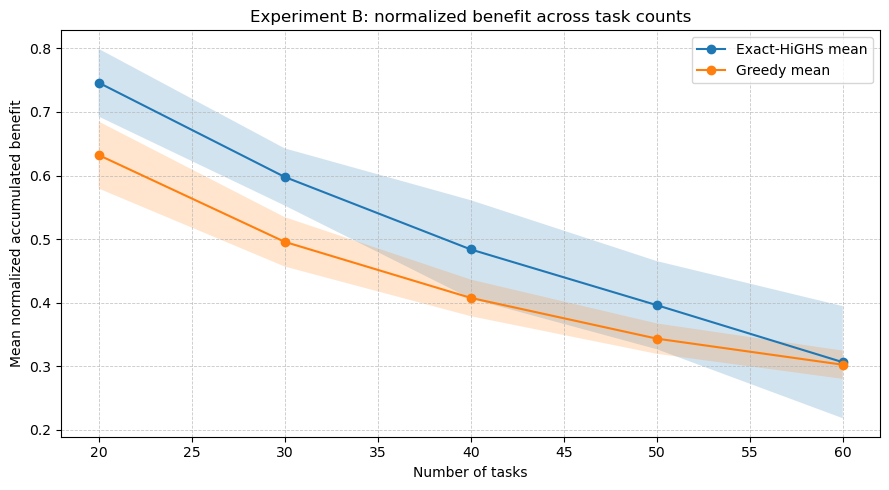

In [21]:
benefit_summary = plot_metric_mean_std(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Mean normalized accumulated benefit",
    title="Experiment B: normalized benefit across task counts",
    methods=["Greedy", "Exact-HiGHS"],
    save_name="fig_01_benefit_mean_std_new.png"
)

In [22]:
# Exact certified scenarios only
certified_exact = df_metrics_scaling[
    (df_metrics_scaling["Method"] == "Exact-HiGHS") &
    (df_metrics_scaling["Optimal Certified"] == True)
][["Tasks", "Scenario"]]

# Convert to set of valid (Tasks, Scenario) pairs
valid_pairs = set(
    zip(certified_exact["Tasks"], certified_exact["Scenario"])
)

# Keep:
# - Exact only if certified
# - Greedy only if its matching Exact scenario was certified
df_quality_B = df_metrics_scaling[
    df_metrics_scaling.apply(
        lambda row: (row["Tasks"], row["Scenario"]) in valid_pairs,
        axis=1
    )
].copy()

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_benefit_certified_pairs
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_benefit_certified_pairs.pdf


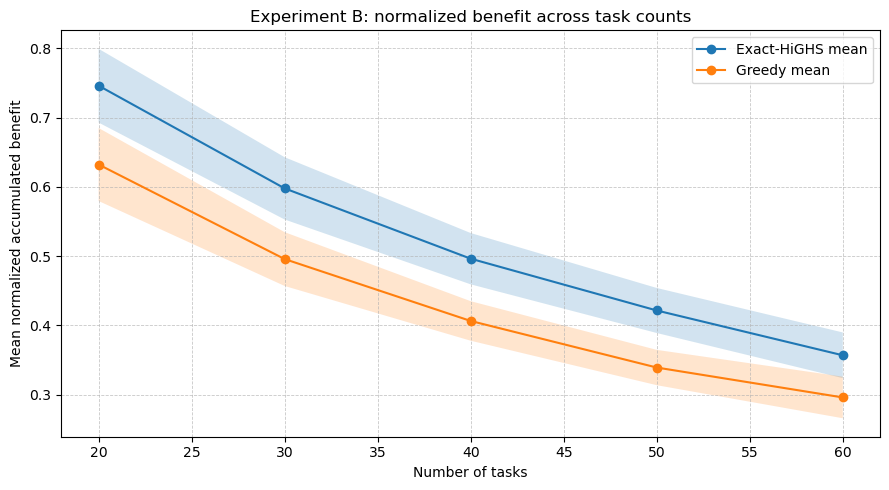

,Tasks,Method,mean,std,count
0,20,Exact-HiGHS,0.746104,0.053240,30
1,20,Greedy,0.632325,0.052689,30
2,30,Exact-HiGHS,0.597874,0.044955,30
3,30,Greedy,0.495819,0.038837,30
4,40,Exact-HiGHS,0.496365,0.037031,29
5,40,Greedy,0.406481,0.028537,29
6,50,Exact-HiGHS,0.421609,0.032497,21
7,50,Greedy,0.339259,0.025490,21
8,60,Exact-HiGHS,0.356932,0.032972,7
9,60,Greedy,0.296086,0.030036,7


In [23]:
plot_metric_mean_std(
    df_quality_B,
    metric="Accumulated Benefit",
    ylabel="Mean normalized accumulated benefit",
    title="Experiment B: normalized benefit across task counts",
    methods=["Exact-HiGHS", "Greedy"],
    save_name="fig_expB_benefit_certified_pairs",
)

In [24]:
# ============================================================
# PAPER-STYLE MEAN ± SD PLOT WITH INSTANCE POINTS
# ============================================================

def plot_metric_mean_std_paper(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    method_labels=None,
    log_y=False,
    save_name=None,
    dpi=2000,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    if method_labels is None:
        method_labels = {
            "Greedy": "Greedy heuristic",
            "Exact-HiGHS": "Exact MILP (HiGHS)",
        }

    summary = (
        df
        .groupby(["Tasks", "Method"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    method_order = methods if methods is not None else sorted(df["Method"].unique())
    offsets = np.linspace(-0.35, 0.35, len(method_order))

    min_positive = df[metric][df[metric] > 0].min()
    positive_floor = min_positive / 10 if pd.notna(min_positive) else 1e-8

    for offset, method in zip(offsets, method_order):
        raw = df[df["Method"] == method].copy()
        grouped = summary[summary["Method"] == method].sort_values("Tasks")

        x = grouped["Tasks"].to_numpy()
        y = grouped["mean"].to_numpy()
        yerr = grouped["std"].fillna(0.0).to_numpy()

        # Individual instance points
        ax.scatter(
            raw["Tasks"] + offset,
            raw[metric],
            alpha=0.35,
            s=30,
        )

        # Mean line
        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            label=f"{method_labels.get(method, method)} mean",
        )

        # ±1 SD band
        lower = y - yerr
        upper = y + yerr

        if log_y:
            lower = np.maximum(lower, positive_floor)

        ax.fill_between(
            x,
            lower,
            upper,
            alpha=0.12,
        )

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_y:
        ax.set_yscale("log")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.legend()

    # Instance annotation
    counts = (
        df.groupby(["Tasks", "Method"])
        .size()
        .reset_index(name="n")
    )

    n_min = counts["n"].min()
    n_max = counts["n"].max()

    if n_min == n_max:
        annotation = f"Points: individual instances; line: mean; band: ±1 SD; n = {n_min} per task size and method"
    else:
        annotation = f"Points: individual instances; line: mean; band: ±1 SD; n = {n_min}–{n_max} per group"

    ax.text(
        0.01,
        -0.20,
        annotation,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )

    fig.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

    return summary

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_01_benefit_mean_std_instances.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_01_benefit_mean_std_instances.pdf


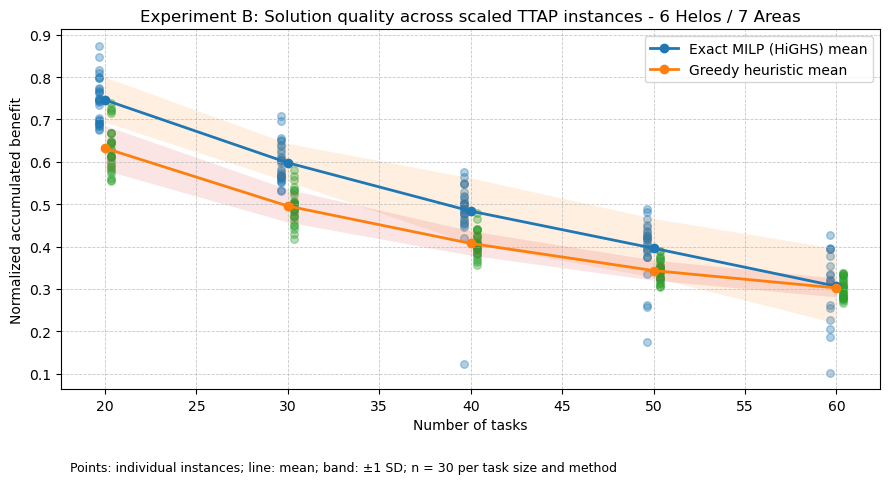

In [25]:
benefit_summary = plot_metric_mean_std_paper(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Normalized accumulated benefit",
    title="Experiment B: Solution quality across scaled TTAP instances - 6 Helos / 7 Areas",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=False,
    save_name="fig_01_benefit_mean_std_instances.png",
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_02_runtime_mean_std.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_02_runtime_mean_std.pdf


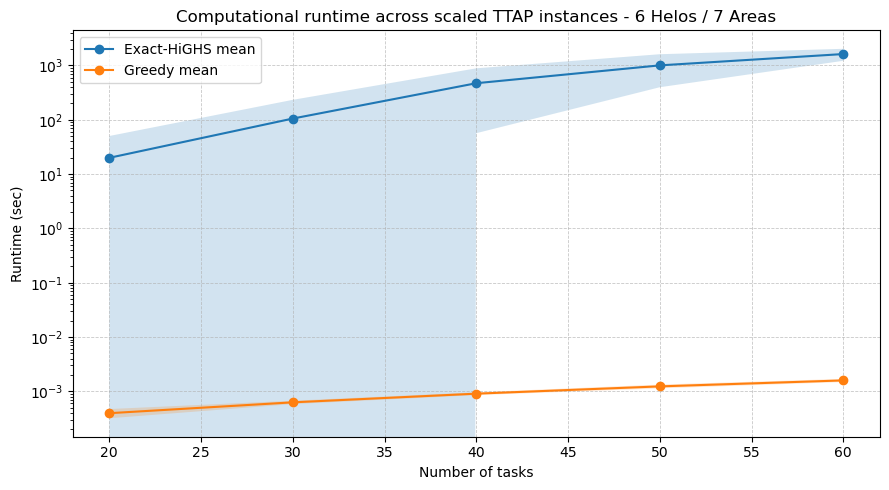

In [26]:
runtime_summary = plot_metric_mean_std(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec)",
    title="Computational runtime across scaled TTAP instances - 6 Helos / 7 Areas",
    methods=["Greedy", "Exact-HiGHS"],
    log_y=True,
    save_name="fig_02_runtime_mean_std.png"
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_02_runtime_mean_std_instances.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_02_runtime_mean_std_instances.pdf


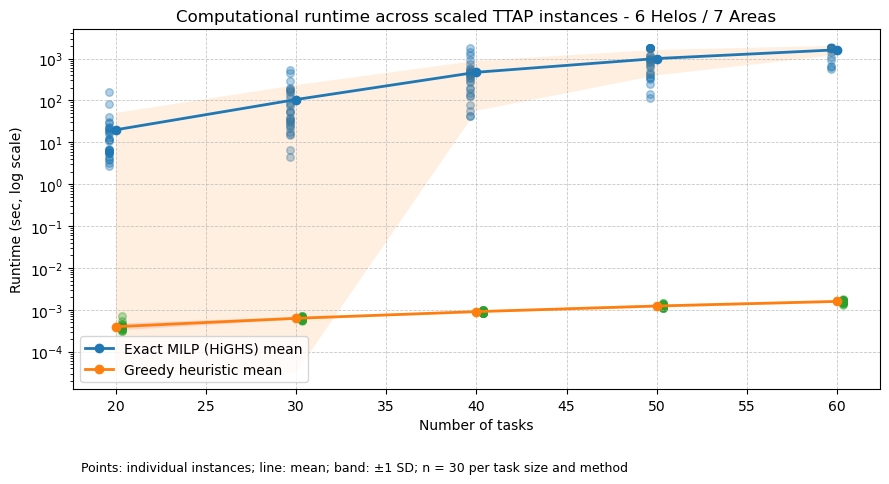

In [27]:
runtime_summary = plot_metric_mean_std_paper(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec, log scale)",
    title="Computational runtime across scaled TTAP instances - 6 Helos / 7 Areas",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=True,
    save_name="fig_02_runtime_mean_std_instances.png",
)

In [28]:
# ============================================================
# BOXPLOT BY TASK SIZE AND METHOD
# ============================================================

def plot_metric_boxplot_by_method(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    save_name=None,
    dpi=300,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    tasks = sorted(df["Tasks"].dropna().unique())
    methods = sorted(df["Method"].dropna().unique())

    n_methods = len(methods)

    width = 0.7 / max(n_methods, 1)
    base_positions = np.arange(len(tasks))

    plt.figure(figsize=(10, 5))

    for m_idx, method in enumerate(methods):
        offset = (m_idx - (n_methods - 1) / 2) * width
        positions = base_positions + offset

        data = [
            df[
                (df["Tasks"] == task_size)
                & (df["Method"] == method)
            ][metric].dropna().to_numpy()
            for task_size in tasks
        ]

        plt.boxplot(
            data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=False,
            showmeans=True,
        )

    plt.xticks(base_positions, [str(t) for t in tasks])
    plt.xlabel("Number of tasks")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

    handles = [
        plt.Line2D([0], [0], marker="s", linestyle="None", label=method)
        for method in methods
    ]

    plt.legend(handles=handles, title="Method")
    plt.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

In [29]:
# ============================================================
# PAPER-STYLE BOXPLOT WITH INSTANCE POINTS
# ============================================================

def plot_metric_boxplot_by_method_paper(
    df_metrics,
    metric,
    ylabel,
    title,
    methods=None,
    method_labels=None,
    log_y=False,
    save_name=None,
    dpi=300,
):
    df = df_metrics.copy()

    if methods is not None:
        df = df[df["Method"].isin(methods)]

    if method_labels is None:
        method_labels = {
            "Greedy": "Greedy heuristic",
            "Exact-HiGHS": "Exact MILP (HiGHS)",
        }

    tasks = sorted(df["Tasks"].dropna().unique())
    method_order = methods if methods is not None else sorted(df["Method"].unique())

    n_methods = len(method_order)
    offsets = np.linspace(-1.2, 1.2, n_methods)
    width = 0.9

    fig, ax = plt.subplots(figsize=(10, 5))

    for offset, method in zip(offsets, method_order):
        data = []
        positions = []

        for task_size in tasks:
            values = df[
                (df["Tasks"] == task_size)
                & (df["Method"] == method)
            ][metric].dropna().to_numpy()

            data.append(values)
            positions.append(task_size + offset)

        ax.boxplot(
            data,
            positions=positions,
            widths=width,
            showmeans=False,
            patch_artist=False,
            manage_ticks=False,
        )

        # Individual points
        for task_size, values in zip(tasks, data):
            if len(values) == 0:
                continue

            jitter = np.linspace(-0.15, 0.15, len(values))
            ax.scatter(
                np.full(len(values), task_size + offset) + jitter,
                values,
                s=30,
                alpha=0.55,
                label=method_labels.get(method, method) if task_size == tasks[0] else None,
            )

    ax.set_xticks(tasks)
    ax.set_xticklabels([str(t) for t in tasks])

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if log_y:
        ax.set_yscale("log")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.legend(title="Method")

    counts = (
        df.groupby(["Tasks", "Method"])
        .size()
        .reset_index(name="n")
    )

    n_min = counts["n"].min()
    n_max = counts["n"].max()

    if n_min < 5:
        note = f"Boxplots are exploratory: n = {n_min} per group. Prefer mean ± SD or increase seeds for final paper."
    elif n_min == n_max:
        note = f"Points: individual instances; box: distribution; n = {n_min} per group."
    else:
        note = f"Points: individual instances; box: distribution; n = {n_min}–{n_max} per group."

    ax.text(
        0.01,
        -0.20,
        note,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
    )

    fig.tight_layout()

    save_current_figure(save_name=save_name, dpi=dpi)

    plt.show()

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_03_benefit_boxplot.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_03_benefit_boxplot.pdf


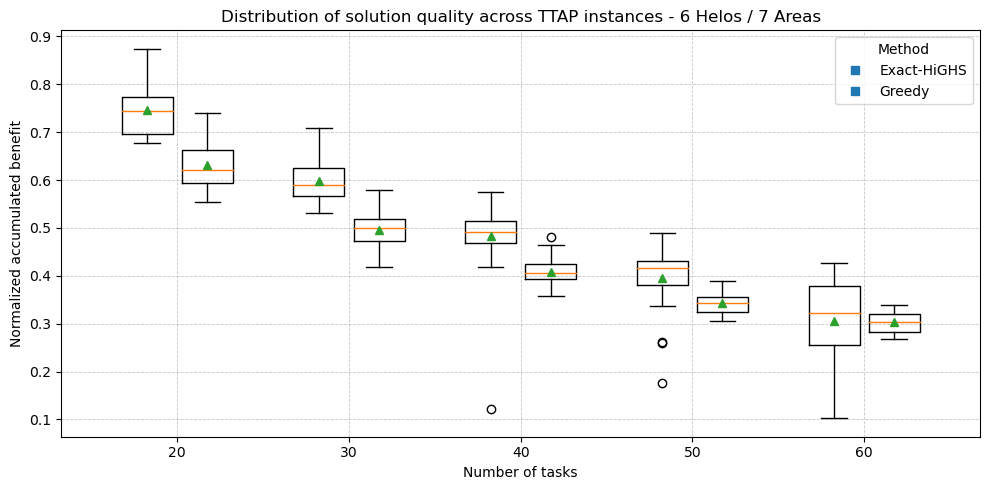

In [30]:
plot_metric_boxplot_by_method(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Normalized accumulated benefit",
    title="Distribution of solution quality across TTAP instances - 6 Helos / 7 Areas",
    methods=["Greedy", "Exact-HiGHS"],
    save_name="fig_03_benefit_boxplot.png"
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_03_benefit_boxplot_instances.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_03_benefit_boxplot_instances.pdf


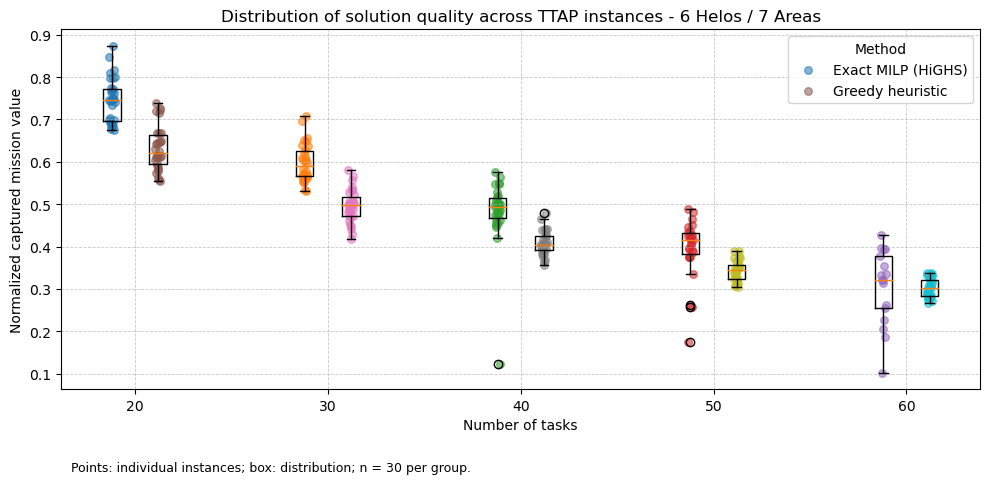

In [31]:
plot_metric_boxplot_by_method_paper(
    df_metrics_scaling,
    metric="Accumulated Benefit",
    ylabel="Normalized captured mission value",
    title="Distribution of solution quality across TTAP instances - 6 Helos / 7 Areas",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=False,
    save_name="fig_03_benefit_boxplot_instances.png",
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_04_runtime_boxplot.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_04_runtime_boxplot.pdf


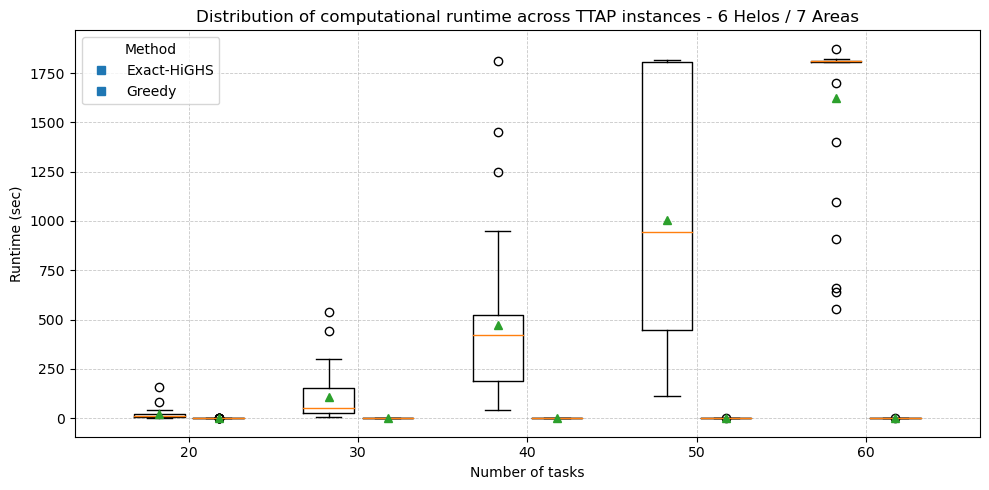

In [32]:
plot_metric_boxplot_by_method(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec)",
    title="Distribution of computational runtime across TTAP instances - 6 Helos / 7 Areas",
    methods=["Greedy", "Exact-HiGHS"],
    save_name="fig_04_runtime_boxplot.png"
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_04_runtime_boxplot_instances.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_04_runtime_boxplot_instances.pdf


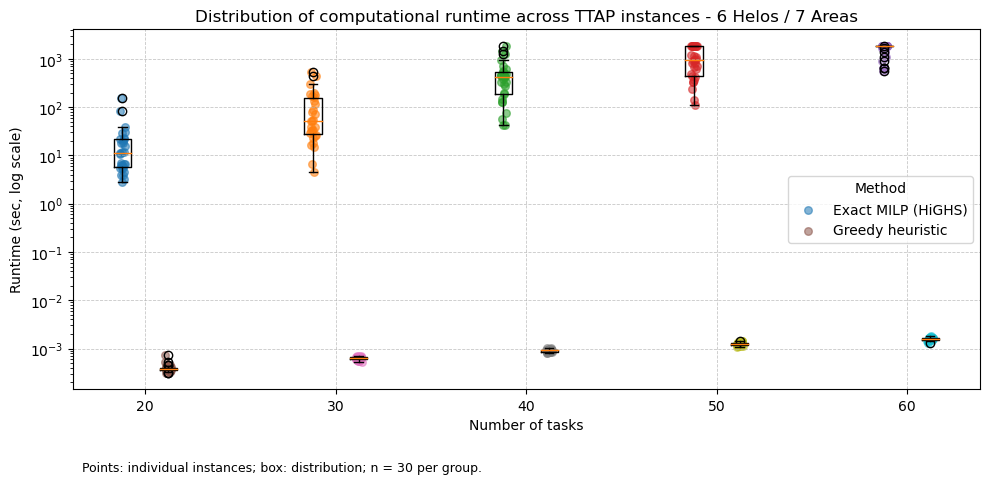

In [33]:
plot_metric_boxplot_by_method_paper(
    df_metrics_scaling,
    metric="Runtime sec",
    ylabel="Runtime (sec, log scale)",
    title="Distribution of computational runtime across TTAP instances - 6 Helos / 7 Areas",
    methods=["Exact-HiGHS", "Greedy"],
    log_y=True,
    save_name="fig_04_runtime_boxplot_instances.png",
)

In [34]:
# ============================================================
# TOTAL RUNTIME BY TASK SIZE FROM EXISTING RESULTS
# ============================================================

def build_total_runtime_by_size(df_metrics):
    df = df_metrics.copy()

    runtime_summary = (
        df
        .groupby(["Tasks", "Method"])
        .agg(
            Instances=("Scenario", "nunique"),
            Total_Runtime_sec=("Runtime sec", "sum"),
            Mean_Runtime_sec=("Runtime sec", "mean"),
            Std_Runtime_sec=("Runtime sec", "std"),
            Min_Runtime_sec=("Runtime sec", "min"),
            Max_Runtime_sec=("Runtime sec", "max"),
        )
        .reset_index()
    )

    return runtime_summary


runtime_total_by_method = build_total_runtime_by_size(df_metrics_scaling)

display(runtime_total_by_method)

,Tasks,Method,Instances,Total_Runtime_sec,Mean_Runtime_sec,Std_Runtime_sec,Min_Runtime_sec,Max_Runtime_sec
0,20,Exact-HiGHS,30,598.124536,19.937485,30.325830,2.794794,156.640527
1,20,Greedy,30,0.011883,0.000396,0.000076,0.000315,0.000728
2,30,Exact-HiGHS,30,3160.552199,105.351740,127.626020,4.571888,538.789361
3,30,Greedy,30,0.018832,0.000628,0.000044,0.000536,0.000710
4,40,Exact-HiGHS,30,14138.966202,471.298873,414.633738,41.833115,1809.795690
5,40,Greedy,30,0.027192,0.000906,0.000054,0.000820,0.001003
6,50,Exact-HiGHS,30,30122.648104,1004.088270,606.637453,112.096812,1815.246738
7,50,Greedy,30,0.037031,0.001234,0.000099,0.001087,0.001453
8,60,Exact-HiGHS,30,48679.315642,1622.643855,403.761446,555.100138,1872.747880
9,60,Greedy,30,0.047693,0.001590,0.000106,0.001325,0.001824


In [35]:
# ============================================================
# CHECK MISSING EXACT INSTANCES
# ============================================================

all_scenarios = set(df_metrics_scaling["Scenario"].unique())

greedy_scenarios = set(
    df_metrics_scaling[df_metrics_scaling["Method"] == "Greedy"]["Scenario"]
)

exact_scenarios = set(
    df_metrics_scaling[df_metrics_scaling["Method"] == "Exact-HiGHS"]["Scenario"]
)

missing_exact = sorted(greedy_scenarios - exact_scenarios)

print("Missing Exact scenarios:")
for s in missing_exact:
    print(s)

Missing Exact scenarios:


In [36]:
print(df_metrics_scaling.columns.tolist())

['Scenario', 'Tasks', 'Method', 'Accumulated Benefit', 'Optimality Gap vs Exact', 'Physical Completed Tasks', 'Physical Completion Rate', 'Positive Benefit Tasks', 'Positive Benefit Completion Rate', 'Operationally Relevant Tasks', 'Operationally Relevant Completion Rate', 'Average Response Time', 'Maximum Response Time', 'Makespan', 'Productive Time', 'Active Time', 'Productive Utilization', 'Active Utilization', 'Total Task Flight Time', 'Total Return Flight Time', 'Total Flight Time', 'Total Recovery Time', 'Operational Cost Proxy', 'Task Count Std', 'Task Count Gini', 'Workload Std', 'Workload Gini', 'Runtime sec', 'Optimal Certified', 'MIP Gap', 'Variables', 'Constraints', 'Nonzeros', 'Solver Message']



Exact certification coverage:


,Generated,Certified,Certification Rate
Tasks,,,
20,30,30,1.000000
30,30,30,1.000000
40,30,29,0.966667
50,30,21,0.700000
60,30,7,0.233333



Certified-pair benefit summary:


,Tasks,Method,mean,std,count
0,20,Exact-HiGHS,0.746104,0.053240,30
1,20,Greedy,0.632325,0.052689,30
2,30,Exact-HiGHS,0.597874,0.044955,30
3,30,Greedy,0.495819,0.038837,30
4,40,Exact-HiGHS,0.496365,0.037031,29
5,40,Greedy,0.406481,0.028537,29
6,50,Exact-HiGHS,0.421609,0.032497,21
7,50,Greedy,0.339259,0.025490,21
8,60,Exact-HiGHS,0.356932,0.032972,7
9,60,Greedy,0.296086,0.030036,7


Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_01_benefit_without_conditional_60.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_01_benefit_without_conditional_60.pdf


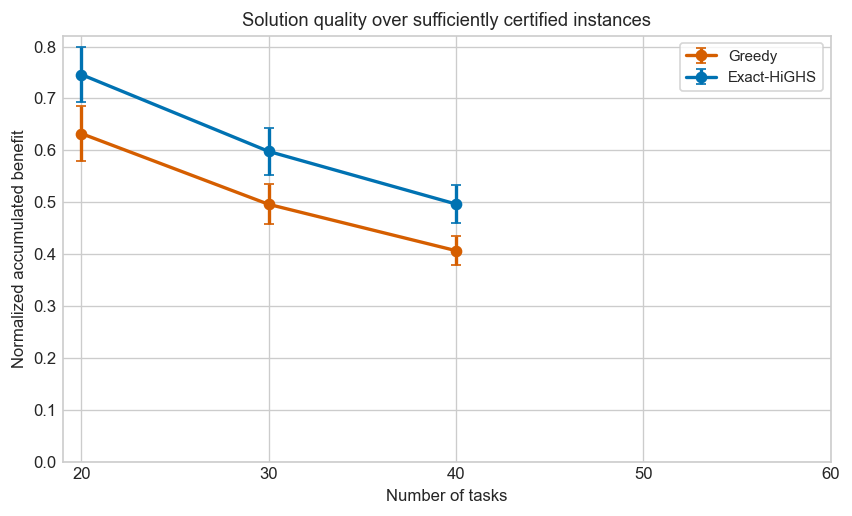

Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_02_benefit_conditional_60.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_02_benefit_conditional_60.pdf


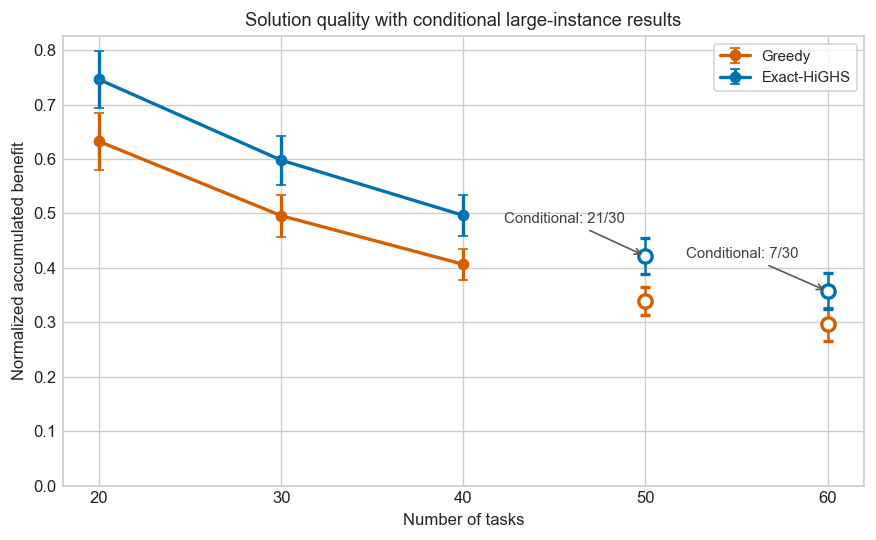

Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_03_benefit_and_completed_tasks.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_03_benefit_and_completed_tasks.pdf


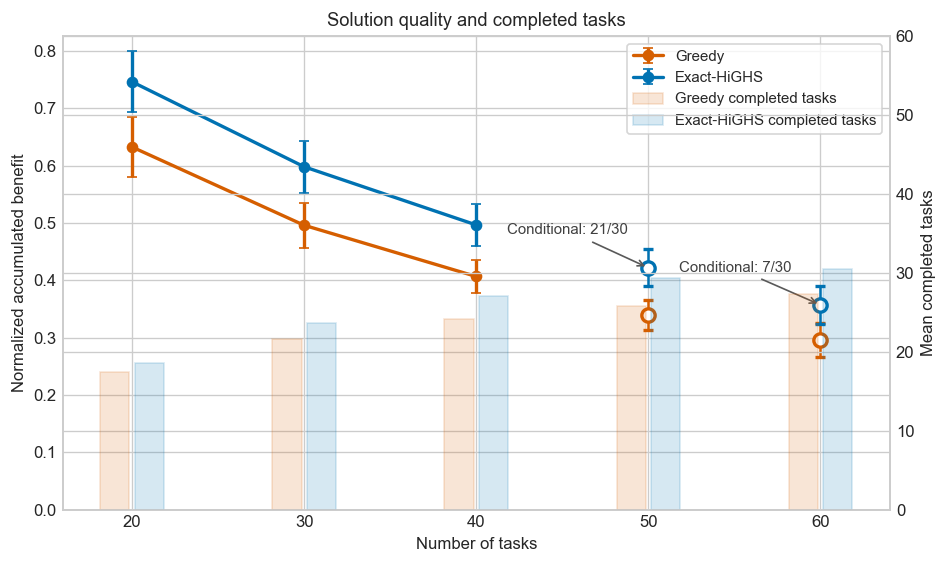

Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_04_certification_and_runtime.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_04_certification_and_runtime.pdf


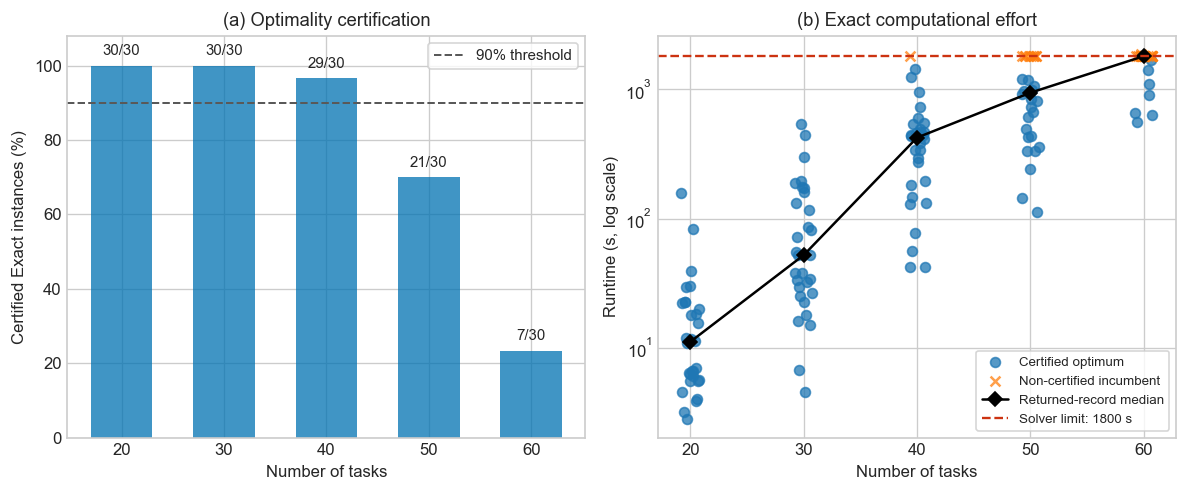

Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_05_certified_gap_distribution.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_05_certified_gap_distribution.pdf


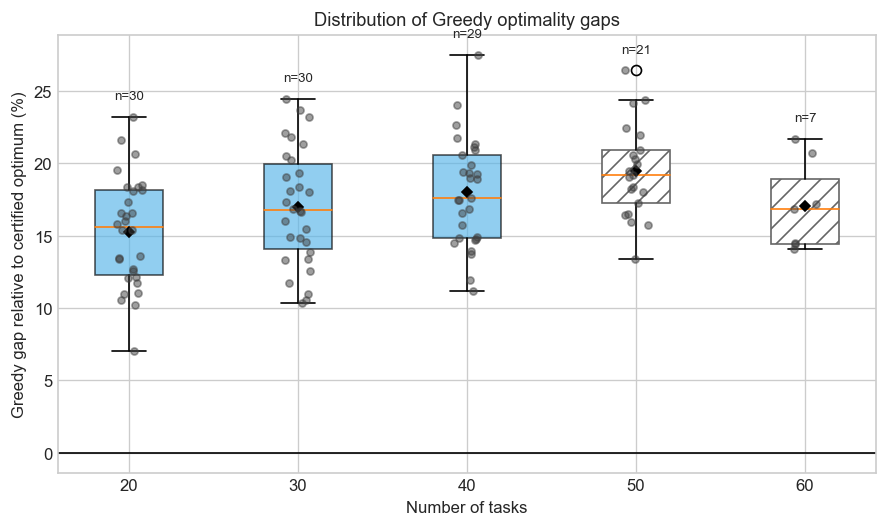

Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_06_model_size_vs_runtime.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_06_model_size_vs_runtime.pdf


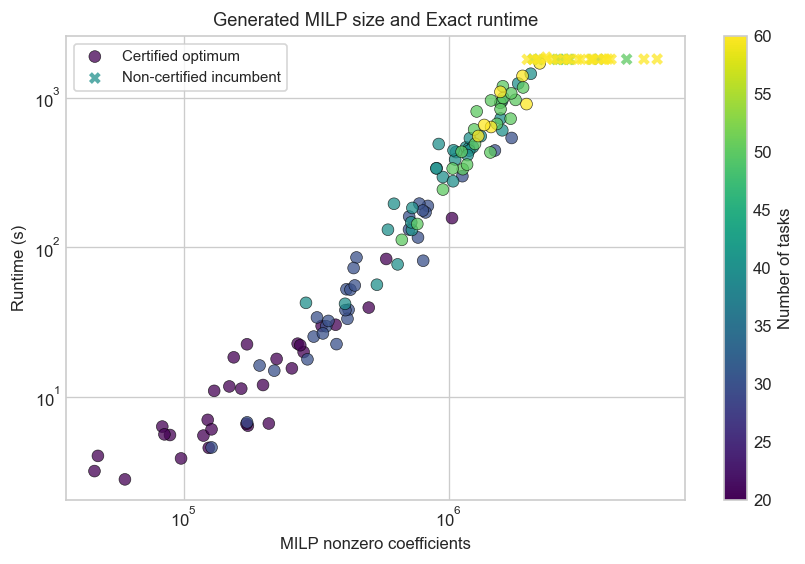


All candidate figures were generated in:
ttap_experiments_6helos_7areas/candidate_figures


In [37]:
# ============================================================
# FIGURAS CANDIDATAS PARA EL PAPER
# Requiere que df_metrics_scaling ya exista
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Cambiar a 3600 si se ejecuta nuevamente con una hora de límite
SOLVER_TIME_LIMIT = 1800

# Cobertura mínima para conectar normalmente un punto Exact
MIN_CERTIFICATION_RATE = 0.90

# Carpeta de salida
BASE_OUTPUT_DIR = Path(
    globals().get("OUTPUT_DIR", "ttap_experiments_6helos_7areas")
)

CANDIDATE_DIR = BASE_OUTPUT_DIR / "candidate_figures"
CANDIDATE_DIR.mkdir(parents=True, exist_ok=True)

# Estilo general
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

COLORS = {
    "Greedy": "#D55E00",
    "Exact-HiGHS": "#0072B2",
}

LABELS = {
    "Greedy": "Greedy",
    "Exact-HiGHS": "Exact-HiGHS",
}

METHODS = ["Greedy", "Exact-HiGHS"]


def save_candidate(fig, filename):
    """Guarda cada figura en PNG y PDF."""
    png_path = CANDIDATE_DIR / f"{filename}.png"
    pdf_path = CANDIDATE_DIR / f"{filename}.pdf"

    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

    plt.show()
    plt.close(fig)


# ============================================================
# 1. PREPARACIÓN DE DATOS
# ============================================================

metrics = df_metrics_scaling.copy()

greedy = metrics[
    metrics["Method"] == "Greedy"
].copy()

exact = metrics[
    metrics["Method"] == "Exact-HiGHS"
].copy()

exact_certified = exact[
    exact["Optimal Certified"] == True
].copy()

task_sizes = sorted(
    greedy["Tasks"].dropna().unique()
)

# Número total de instancias, usando Greedy como referencia
generated_counts = (
    greedy.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

# Número de óptimos certificados
certified_counts = (
    exact_certified.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

coverage = pd.DataFrame({
    "Generated": generated_counts,
    "Certified": certified_counts,
})

coverage["Certification Rate"] = (
    coverage["Certified"] / coverage["Generated"]
)

reliable_tasks = coverage.index[
    coverage["Certification Rate"] >= MIN_CERTIFICATION_RATE
].tolist()

conditional_tasks = coverage.index[
    coverage["Certification Rate"] < MIN_CERTIFICATION_RATE
].tolist()

# Pares Exact-Greedy correspondientes solamente a Exact certificado
certified_keys = exact_certified[
    ["Tasks", "Scenario"]
].drop_duplicates()

paired = metrics.merge(
    certified_keys,
    on=["Tasks", "Scenario"],
    how="inner",
)

quality_summary = (
    paired.groupby(["Tasks", "Method"])["Accumulated Benefit"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

operational_summary = (
    paired.groupby(["Tasks", "Method"])
    .agg(
        Completed=("Physical Completed Tasks", "mean"),
        Relevant=("Operationally Relevant Tasks", "mean"),
        Flight=("Total Flight Time", "mean"),
    )
    .reset_index()
)

print("\nExact certification coverage:")
display(coverage)

print("\nCertified-pair benefit summary:")
display(quality_summary)


# ============================================================
# FUNCIÓN PARA GRAFICAR BENEFICIO EMPAREJADO
# ============================================================

def plot_paired_benefit(
    ax,
    show_conditional=False,
    title=None,
):
    """
    Dibuja los promedios Exact-Greedy usando solamente
    pares con Exact certificado.
    """

    for method in METHODS:

        method_data = quality_summary[
            quality_summary["Method"] == method
        ].sort_values("Tasks")

        reliable_data = method_data[
            method_data["Tasks"].isin(reliable_tasks)
        ]

        ax.errorbar(
            reliable_data["Tasks"],
            reliable_data["mean"],
            yerr=reliable_data["std"].fillna(0),
            fmt="o-",
            linewidth=2,
            markersize=6,
            capsize=3,
            color=COLORS[method],
            label=LABELS[method],
        )

        if show_conditional:

            conditional_data = method_data[
                method_data["Tasks"].isin(conditional_tasks)
            ]

            ax.errorbar(
                conditional_data["Tasks"],
                conditional_data["mean"],
                yerr=conditional_data["std"].fillna(0),
                fmt="o",
                linestyle="none",
                markersize=8,
                markerfacecolor="white",
                markeredgewidth=2,
                capsize=3,
                color=COLORS[method],
            )

    if show_conditional:

        for task_count in conditional_tasks:

            exact_point = quality_summary[
                (quality_summary["Tasks"] == task_count) &
                (quality_summary["Method"] == "Exact-HiGHS")
            ]

            if not exact_point.empty:

                y_value = exact_point["mean"].iloc[0]
                certified = int(coverage.loc[task_count, "Certified"])
                generated = int(coverage.loc[task_count, "Generated"])

                ax.annotate(
                    f"Conditional: {certified}/{generated}",
                    xy=(task_count, y_value),
                    xytext=(-85, 20),
                    textcoords="offset points",
                    arrowprops={
                        "arrowstyle": "->",
                        "color": "0.35",
                    },
                    fontsize=9,
                    color="0.25",
                )

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel("Normalized accumulated benefit")
    ax.set_xticks(task_sizes)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=True)

    if title is not None:
        ax.set_title(title)


# ============================================================
# FIGURA 1
# Comparación principal sin el punto Exact condicional de T60
# ============================================================

fig, ax = plt.subplots(figsize=(7.2, 4.4))

plot_paired_benefit(
    ax,
    show_conditional=False,
    title="Solution quality over sufficiently certified instances",
)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_01_benefit_without_conditional_60",
)


# ============================================================
# FIGURA 2
# Comparación incluyendo T60 como marcador condicional
# ============================================================

fig, ax = plt.subplots(figsize=(7.4, 4.6))

plot_paired_benefit(
    ax,
    show_conditional=True,
    title="Solution quality with conditional large-instance results",
)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_02_benefit_conditional_60",
)


# ============================================================
# FIGURA 3
# Beneficio y tareas completadas en dos ejes
# Barras transparentes para las tareas
# ============================================================

fig, ax_benefit = plt.subplots(figsize=(8.0, 4.8))

plot_paired_benefit(
    ax_benefit,
    show_conditional=True,
    title="Solution quality and completed tasks",
)

ax_tasks = ax_benefit.twinx()

bar_width = 1.7
offsets = {
    "Greedy": -1.0,
    "Exact-HiGHS": 1.0,
}

for method in METHODS:

    method_operational = operational_summary[
        operational_summary["Method"] == method
    ].sort_values("Tasks")

    ax_tasks.bar(
        method_operational["Tasks"] + offsets[method],
        method_operational["Completed"],
        width=bar_width,
        color=COLORS[method],
        alpha=0.16,
        edgecolor=COLORS[method],
        linewidth=1.0,
        label=f"{LABELS[method]} completed tasks",
    )

ax_tasks.set_ylabel("Mean completed tasks")
ax_tasks.set_ylim(0, max(task_sizes))

# Combinar las leyendas de ambos ejes
handles_1, labels_1 = ax_benefit.get_legend_handles_labels()
handles_2, labels_2 = ax_tasks.get_legend_handles_labels()

ax_benefit.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="best",
    frameon=True,
)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_03_benefit_and_completed_tasks",
)


# ============================================================
# FIGURA 4
# Cobertura de optimalidad y runtime Exact
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.0, 4.2),
)

# Panel A: tasa de certificación
ax = axes[0]

bars = ax.bar(
    coverage.index,
    100 * coverage["Certification Rate"],
    width=6,
    color="#0072B2",
    alpha=0.75,
)

for bar, task_count in zip(bars, coverage.index):

    certified = int(coverage.loc[task_count, "Certified"])
    generated = int(coverage.loc[task_count, "Generated"])

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{certified}/{generated}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.axhline(
    100 * MIN_CERTIFICATION_RATE,
    color="0.35",
    linestyle="--",
    linewidth=1.2,
    label=f"{MIN_CERTIFICATION_RATE:.0%} threshold",
)

ax.set_xlabel("Number of tasks")
ax.set_ylabel("Certified Exact instances (%)")
ax.set_title("(a) Optimality certification")
ax.set_xticks(task_sizes)
ax.set_ylim(0, 108)
ax.legend(frameon=True)

# Panel B: runtime individual
ax = axes[1]

rng = np.random.default_rng(7)

for certified_status, marker, label in [
    (True, "o", "Certified optimum"),
    (False, "x", "Non-certified incumbent"),
]:

    subset = exact[
        exact["Optimal Certified"] == certified_status
    ].copy()

    jitter = rng.uniform(
        -0.8,
        0.8,
        size=len(subset),
    )

    ax.scatter(
        subset["Tasks"] + jitter,
        subset["Runtime sec"],
        marker=marker,
        s=35,
        alpha=0.75,
        label=label,
    )

runtime_median = (
    exact.groupby("Tasks")["Runtime sec"]
    .median()
    .reindex(task_sizes)
)

ax.plot(
    task_sizes,
    runtime_median,
    color="black",
    marker="D",
    linewidth=1.5,
    label="Returned-record median",
)

ax.axhline(
    SOLVER_TIME_LIMIT,
    color="#CC3311",
    linestyle="--",
    linewidth=1.4,
    label=f"Solver limit: {SOLVER_TIME_LIMIT} s",
)

ax.set_yscale("log")
ax.set_xlabel("Number of tasks")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("(b) Exact computational effort")
ax.set_xticks(task_sizes)
ax.legend(frameon=True, fontsize=8)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_04_certification_and_runtime",
)


# ============================================================
# FIGURA 5
# Distribución del gap Greedy frente al óptimo certificado
# ============================================================

paired_wide = paired.pivot(
    index=["Tasks", "Scenario"],
    columns="Method",
    values="Accumulated Benefit",
).reset_index()

paired_wide["Greedy Gap (%)"] = (
    100
    * (
        paired_wide["Exact-HiGHS"]
        - paired_wide["Greedy"]
    )
    / paired_wide["Exact-HiGHS"]
)

gap_data = []
gap_positions = []

for task_count in task_sizes:

    values = paired_wide.loc[
        paired_wide["Tasks"] == task_count,
        "Greedy Gap (%)",
    ].dropna().to_numpy()

    if len(values) > 0:
        gap_data.append(values)
        gap_positions.append(task_count)

fig, ax = plt.subplots(figsize=(7.5, 4.5))

boxplot = ax.boxplot(
    gap_data,
    positions=gap_positions,
    widths=4,
    patch_artist=True,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 4,
    },
)

for patch, task_count in zip(
    boxplot["boxes"],
    gap_positions,
):

    if task_count in conditional_tasks:
        patch.set_facecolor("white")
        patch.set_edgecolor("0.4")
        patch.set_hatch("//")
    else:
        patch.set_facecolor("#56B4E9")
        patch.set_alpha(0.65)

for task_count, values in zip(
    gap_positions,
    gap_data,
):

    jitter = rng.uniform(
        -0.8,
        0.8,
        size=len(values),
    )

    ax.scatter(
        task_count + jitter,
        values,
        s=18,
        color="0.25",
        alpha=0.50,
        zorder=3,
    )

    ax.text(
        task_count,
        max(values) + 1.0,
        f"n={len(values)}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.axhline(
    0,
    color="black",
    linewidth=1,
)

ax.set_xlabel("Number of tasks")
ax.set_ylabel("Greedy gap relative to certified optimum (%)")
ax.set_title("Distribution of Greedy optimality gaps")
ax.set_xticks(task_sizes)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_05_certified_gap_distribution",
)


# ============================================================
# FIGURA 6
# Tamaño de la formulación frente al runtime Exact
# ============================================================

exact_size = exact.dropna(
    subset=["Nonzeros", "Runtime sec"]
).copy()

fig, ax = plt.subplots(figsize=(7.2, 4.8))

task_min = exact_size["Tasks"].min()
task_max = exact_size["Tasks"].max()

normalization = plt.Normalize(
    task_min,
    task_max,
)

for certified_status, marker, label in [
    (True, "o", "Certified optimum"),
    (False, "X", "Non-certified incumbent"),
]:

    subset = exact_size[
        exact_size["Optimal Certified"] == certified_status
    ]

    ax.scatter(
        subset["Nonzeros"],
        subset["Runtime sec"],
        c=subset["Tasks"],
        cmap="viridis",
        norm=normalization,
        marker=marker,
        s=50,
        alpha=0.75,
        edgecolor="black" if certified_status else "none",
        linewidth=0.4,
        label=label,
    )

color_mapper = plt.cm.ScalarMappable(
    norm=normalization,
    cmap="viridis",
)

colorbar = fig.colorbar(
    color_mapper,
    ax=ax,
)

colorbar.set_label("Number of tasks")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("MILP nonzero coefficients")
ax.set_ylabel("Runtime (s)")
ax.set_title("Generated MILP size and Exact runtime")
ax.legend(frameon=True)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_06_model_size_vs_runtime",
)


print("\nAll candidate figures were generated in:")
print(CANDIDATE_DIR)

Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_07_greedy_all_exact_certified.png
Saved: ttap_experiments_6helos_7areas/candidate_figures/candidate_07_greedy_all_exact_certified.pdf


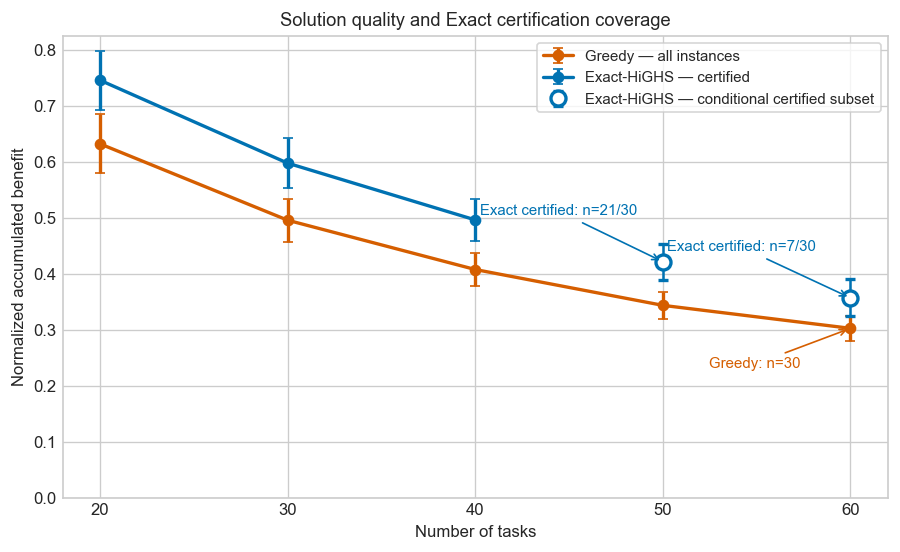

In [38]:
# ============================================================
# BENEFICIO:
# Greedy usa todas las instancias disponibles.
# Exact usa solamente soluciones certificadas.
# ============================================================

greedy_all_summary = (
    greedy.groupby("Tasks")["Accumulated Benefit"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

exact_certified_summary = (
    exact_certified.groupby("Tasks")["Accumulated Benefit"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7.6, 4.7))

# ------------------------------------------------------------
# Greedy: todas las instancias, incluyendo 60 tareas
# ------------------------------------------------------------

ax.errorbar(
    greedy_all_summary["Tasks"],
    greedy_all_summary["mean"],
    yerr=greedy_all_summary["std"],
    fmt="o-",
    color=COLORS["Greedy"],
    linewidth=2,
    markersize=6,
    capsize=3,
    label="Greedy — all instances",
)

# ------------------------------------------------------------
# Exact: tamaños con cobertura suficiente
# ------------------------------------------------------------

exact_reliable = exact_certified_summary[
    exact_certified_summary["Tasks"].isin(reliable_tasks)
]

ax.errorbar(
    exact_reliable["Tasks"],
    exact_reliable["mean"],
    yerr=exact_reliable["std"],
    fmt="o-",
    color=COLORS["Exact-HiGHS"],
    linewidth=2,
    markersize=6,
    capsize=3,
    label="Exact-HiGHS — certified",
)

# ------------------------------------------------------------
# Exact: resultados condicionales, actualmente 60 tareas
# ------------------------------------------------------------

exact_conditional = exact_certified_summary[
    exact_certified_summary["Tasks"].isin(conditional_tasks)
]

ax.errorbar(
    exact_conditional["Tasks"],
    exact_conditional["mean"],
    yerr=exact_conditional["std"],
    fmt="o",
    linestyle="none",
    color=COLORS["Exact-HiGHS"],
    markerfacecolor="white",
    markeredgewidth=2,
    markersize=9,
    capsize=3,
    label="Exact-HiGHS — conditional certified subset",
)

# ------------------------------------------------------------
# Anotaciones con tamaños muestrales
# ------------------------------------------------------------

for _, row in greedy_all_summary.iterrows():

    if row["Tasks"] == max(task_sizes):

        ax.annotate(
            f'Greedy: n={int(row["count"])}',
            xy=(row["Tasks"], row["mean"]),
            xytext=(-85, -24),
            textcoords="offset points",
            color=COLORS["Greedy"],
            fontsize=9,
            arrowprops={
                "arrowstyle": "->",
                "color": COLORS["Greedy"],
            },
        )

for _, row in exact_conditional.iterrows():

    total_instances = int(
        coverage.loc[row["Tasks"], "Generated"]
    )

    ax.annotate(
        f'Exact certified: n={int(row["count"])}/{total_instances}',
        xy=(row["Tasks"], row["mean"]),
        xytext=(-110, 28),
        textcoords="offset points",
        color=COLORS["Exact-HiGHS"],
        fontsize=9,
        arrowprops={
            "arrowstyle": "->",
            "color": COLORS["Exact-HiGHS"],
        },
    )

ax.set_xlabel("Number of tasks")
ax.set_ylabel("Normalized accumulated benefit")
ax.set_title("Solution quality and Exact certification coverage")
ax.set_xticks(task_sizes)
ax.set_ylim(bottom=0)
ax.legend(frameon=True)

fig.tight_layout()

save_candidate(
    fig,
    "candidate_07_greedy_all_exact_certified",
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_benefit_coverage_aware_2.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_benefit_coverage_aware_2.pdf


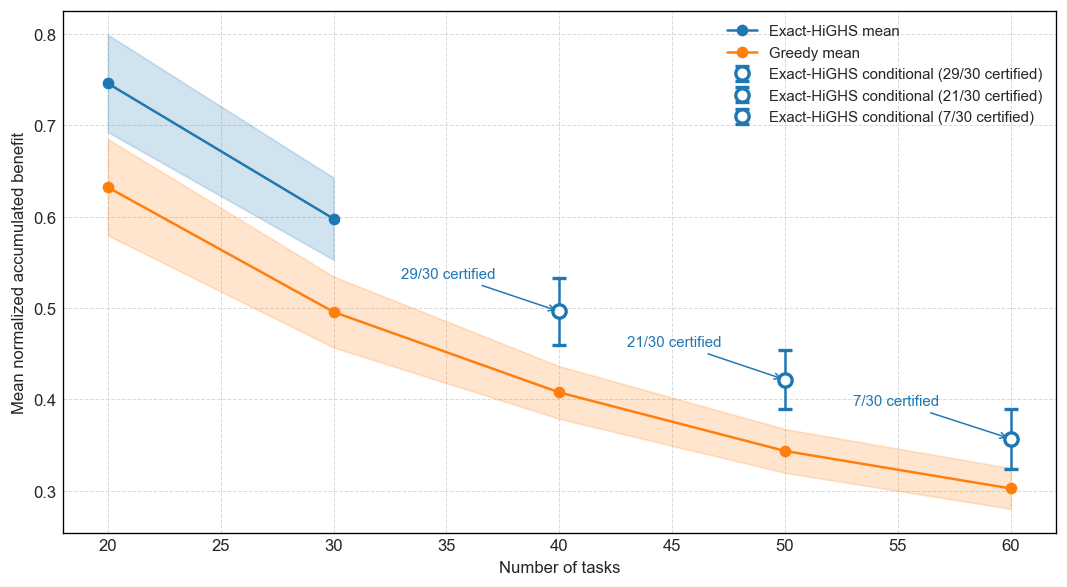

,Generated,Exact certified,Certification rate
Tasks,,,
20,30,30,1.000000
30,30,30,1.000000
40,30,29,0.966667
50,30,21,0.700000
60,30,7,0.233333


In [51]:
# ============================================================
# EXPERIMENT B — BENEFIT WITH COVERAGE-AWARE EXACT RESULTS
# Misma estética que:
# "Experiment B: normalized benefit across task counts"
# ============================================================

SHOW_CONDITIONAL_EXACT = True
MIN_CERTIFICATION_RATE = 0.99

metrics = df_metrics_scaling.copy()

greedy = metrics[
    metrics["Method"] == "Greedy"
].copy()

exact = metrics[
    metrics["Method"] == "Exact-HiGHS"
].copy()

exact_certified = exact[
    exact["Optimal Certified"] == True
].copy()

task_sizes = sorted(
    greedy["Tasks"].dropna().unique()
)

# ------------------------------------------------------------
# Cobertura Exact
# ------------------------------------------------------------

generated_counts = (
    greedy.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

certified_counts = (
    exact_certified.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

certification_rate = (
    certified_counts / generated_counts
)

reliable_tasks = certification_rate[
    certification_rate >= MIN_CERTIFICATION_RATE
].index.tolist()

conditional_tasks = certification_rate[
    certification_rate < MIN_CERTIFICATION_RATE
].index.tolist()

# ------------------------------------------------------------
# Resúmenes: media ± desviación estándar
# ------------------------------------------------------------

greedy_summary_all = (
    greedy.groupby("Tasks")["Accumulated Benefit"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("Tasks")
)

exact_summary_certified = (
    exact_certified.groupby("Tasks")["Accumulated Benefit"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values("Tasks")
)

# Colores predeterminados utilizados por Matplotlib
EXACT_COLOR = "#1f77b4"
GREEDY_COLOR = "#ff7f0e"

fig, ax = plt.subplots(figsize=(9, 5))

# ============================================================
# EXACT — primero para mantener el color azul original
# ============================================================

exact_reliable = exact_summary_certified[
    exact_summary_certified["Tasks"].isin(reliable_tasks)
].copy()

x_exact = exact_reliable["Tasks"].to_numpy()
y_exact = exact_reliable["mean"].to_numpy()
sd_exact = exact_reliable["std"].fillna(0.0).to_numpy()

ax.plot(
    x_exact,
    y_exact,
    marker="o",
    color=EXACT_COLOR,
    label="Exact-HiGHS mean",
)

ax.fill_between(
    x_exact,
    y_exact - sd_exact,
    y_exact + sd_exact,
    color=EXACT_COLOR,
    alpha=0.20,
)

# ------------------------------------------------------------
# Exact condicional: marcador vacío y no conectado
# ------------------------------------------------------------

if SHOW_CONDITIONAL_EXACT:

    exact_conditional = exact_summary_certified[
        exact_summary_certified["Tasks"].isin(
            conditional_tasks
        )
    ].copy()

    for _, row in exact_conditional.iterrows():

        task_count = int(row["Tasks"])
        mean_value = row["mean"]
        std_value = (
            0.0
            if pd.isna(row["std"])
            else row["std"]
        )

        certified_n = int(row["count"])
        generated_n = int(
            generated_counts.loc[task_count]
        )

        ax.errorbar(
            task_count,
            mean_value,
            yerr=std_value,
            fmt="o",
            linestyle="none",
            markersize=8,
            markerfacecolor="white",
            markeredgecolor=EXACT_COLOR,
            markeredgewidth=2,
            ecolor=EXACT_COLOR,
            capsize=4,
            label=(
                f"Exact-HiGHS conditional "
                f"({certified_n}/{generated_n} certified)"
            ),
        )

        ax.annotate(
            f"{certified_n}/{generated_n} certified",
            xy=(task_count, mean_value),
            xytext=(-95, 20),
            textcoords="offset points",
            fontsize=9,
            color=EXACT_COLOR,
            arrowprops={
                "arrowstyle": "->",
                "color": EXACT_COLOR,
                "linewidth": 0.9,
            },
        )

# ============================================================
# GREEDY — todas las instancias, incluyendo 60 tareas
# ============================================================

x_greedy = greedy_summary_all["Tasks"].to_numpy()
y_greedy = greedy_summary_all["mean"].to_numpy()
sd_greedy = (
    greedy_summary_all["std"]
    .fillna(0.0)
    .to_numpy()
)

ax.plot(
    x_greedy,
    y_greedy,
    marker="o",
    color=GREEDY_COLOR,
    label="Greedy mean",
)

ax.fill_between(
    x_greedy,
    y_greedy - sd_greedy,
    y_greedy + sd_greedy,
    color=GREEDY_COLOR,
    alpha=0.20,
)

# ============================================================
# CONFIGURACIÓN IDÉNTICA AL GRÁFICO ORIGINAL
# ============================================================

ax.set_xlabel("Number of tasks")
ax.set_ylabel("Mean normalized accumulated benefit")

#ax.set_title("Experiment B: normalized benefit across task counts")

ax.set_xticks(task_sizes)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.7,
)

ax.legend()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8) 

ax.set_xlim(18, 62)
ax.set_xticks([20, 25, 30, 35, 40, 45, 50, 55, 60])

fig.tight_layout()

save_current_figure(
    save_name="fig_expB_benefit_coverage_aware_2.png",
    dpi=2000,
)

plt.show()

# Tabla de control
display(
    pd.DataFrame({
        "Generated": generated_counts,
        "Exact certified": certified_counts,
        "Certification rate": certification_rate,
    })
)

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_feasible_arcs_vs_runtime.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_feasible_arcs_vs_runtime.pdf


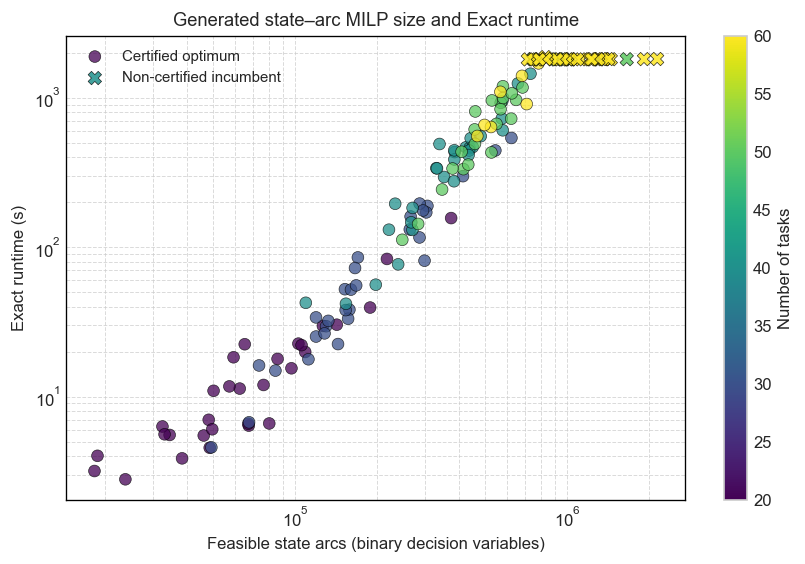

In [40]:
# ============================================================
# GENERATED STATE-ARC MILP SIZE AND EXACT RUNTIME
# Variables = número de arcos factibles
# ============================================================

exact_size = exact.dropna(
    subset=["Variables", "Runtime sec"]
).copy()

fig, ax = plt.subplots(figsize=(7.2, 4.8))

task_min = exact_size["Tasks"].min()
task_max = exact_size["Tasks"].max()

normalization = plt.Normalize(
    task_min,
    task_max,
)

# ------------------------------------------------------------
# Óptimos certificados
# ------------------------------------------------------------

certified_subset = exact_size[
    exact_size["Optimal Certified"] == True
]

ax.scatter(
    certified_subset["Variables"],
    certified_subset["Runtime sec"],
    c=certified_subset["Tasks"],
    cmap="viridis",
    norm=normalization,
    marker="o",
    s=50,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.4,
    label="Certified optimum",
)

# ------------------------------------------------------------
# Incumbentes no certificados
# ------------------------------------------------------------

noncertified_subset = exact_size[
    exact_size["Optimal Certified"] == False
]

ax.scatter(
    noncertified_subset["Variables"],
    noncertified_subset["Runtime sec"],
    c=noncertified_subset["Tasks"],
    cmap="viridis",
    norm=normalization,
    marker="X",
    s=65,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.4,
    label="Non-certified incumbent",
)

# ------------------------------------------------------------
# Barra de color
# ------------------------------------------------------------

color_mapper = plt.cm.ScalarMappable(
    norm=normalization,
    cmap="viridis",
)

color_mapper.set_array([])

colorbar = fig.colorbar(
    color_mapper,
    ax=ax,
)

colorbar.set_label("Number of tasks")

# ------------------------------------------------------------
# Configuración
# ------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    "Feasible state arcs (binary decision variables)"
)

ax.set_ylabel("Exact runtime (s)")

ax.set_title(
    "Generated state–arc MILP size and Exact runtime"
)

ax.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.7,
)

ax.legend()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8) 

fig.tight_layout()

save_current_figure(
    save_name="fig_expB_feasible_arcs_vs_runtime.png",
    dpi=1000,
)

plt.show()

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_exact_computational_effort_and_state_arc_size_1.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_exact_computational_effort_and_state_arc_size_1.pdf


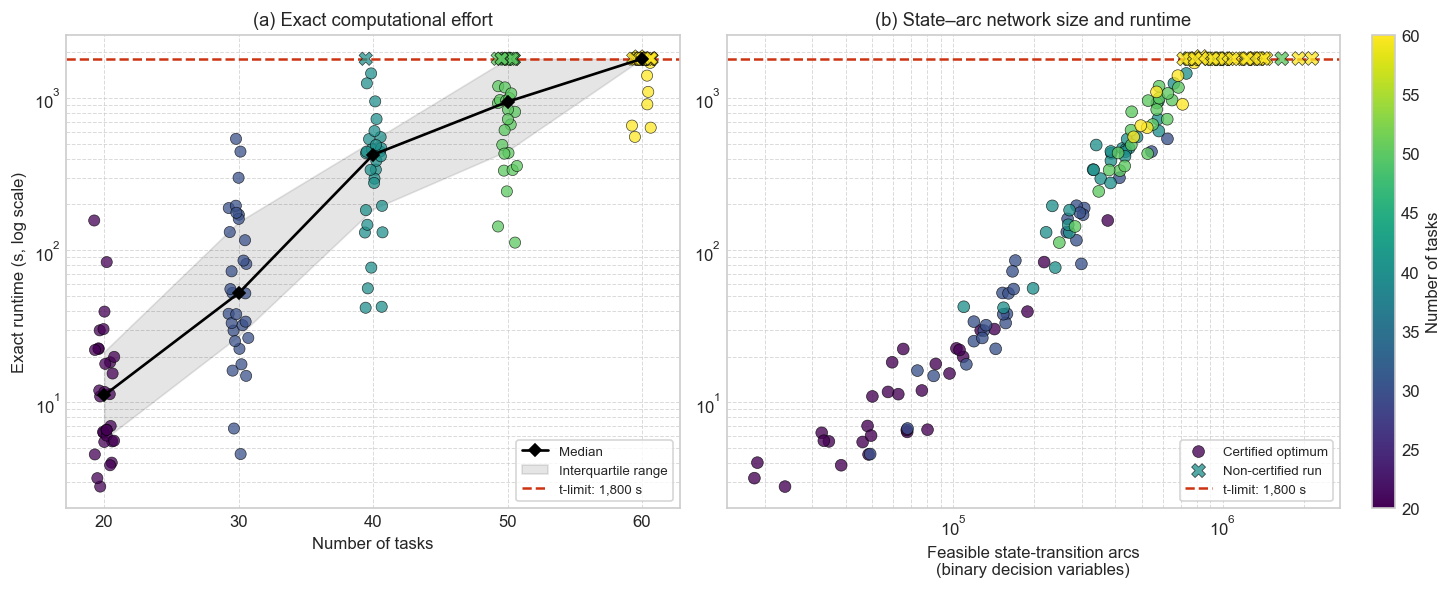

In [49]:
# ============================================================
# COMBINED COMPUTATIONAL FIGURE
# (a) Exact computational effort
# (b) Feasible state-transition arcs versus runtime
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SOLVER_TIME_LIMIT = 1800

metrics = df_metrics_scaling.copy()

greedy = metrics[
    metrics["Method"] == "Greedy"
].copy()

exact = metrics[
    metrics["Method"] == "Exact-HiGHS"
].copy()

exact_size = exact.dropna(
    subset=["Variables", "Runtime sec"]
).copy()

task_sizes = sorted(
    greedy["Tasks"].dropna().unique()
)

# ------------------------------------------------------------
# Cobertura de certificación
# ------------------------------------------------------------

generated_counts = (
    greedy.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

certified_counts = (
    exact[
        exact["Optimal Certified"] == True
    ]
    .groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

# ------------------------------------------------------------
# Configuración cromática común
# ------------------------------------------------------------

task_min = min(task_sizes)
task_max = max(task_sizes)

normalization = plt.Normalize(
    task_min,
    task_max,
)

cmap = plt.get_cmap("viridis")

rng = np.random.default_rng(7)

# ============================================================
# CREAR FIGURA DE DOS PANELES
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
    constrained_layout=True,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.8) 

ax_effort = axes[0]
ax_structure = axes[1]

# ============================================================
# PANEL (a): EXACT COMPUTATIONAL EFFORT
# ============================================================

for certified_status, marker in [
    (True, "o"),
    (False, "X"),
]:

    subset = exact_size[
        exact_size["Optimal Certified"]
        == certified_status
    ].copy()

    jitter = rng.uniform(
        -0.75,
        0.75,
        size=len(subset),
    )

    ax_effort.scatter(
        subset["Tasks"] + jitter,
        subset["Runtime sec"],
        c=subset["Tasks"],
        cmap=cmap,
        norm=normalization,
        marker=marker,
        s=45 if certified_status else 65,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
    )

# Mediana de los registros Exact retornados
runtime_summary = (
    exact_size.groupby("Tasks")["Runtime sec"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
    )
    .reindex(task_sizes)
)

ax_effort.plot(
    task_sizes,
    runtime_summary["median"],
    color="black",
    marker="D",
    markersize=5,
    linewidth=1.6,
    label="Median",
    zorder=4,
)

# Rango intercuartílico
ax_effort.fill_between(
    task_sizes,
    runtime_summary["q25"],
    runtime_summary["q75"],
    color="black",
    alpha=0.10,
    label="Interquartile range",
)

# Límite del solver
ax_effort.axhline(
    SOLVER_TIME_LIMIT,
    color="#CC3311",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"t-limit: "
        f"{SOLVER_TIME_LIMIT:,} s"
    ),
)

# Indicar certificados / generados
for task_count in task_sizes:

    certified_n = int(
        certified_counts.loc[task_count]
    )

    generated_n = int(
        generated_counts.loc[task_count]
    )

    #ax_effort.text(
    #    task_count,
    #    1.025,
    #    f"{certified_n}/{generated_n}",
    #    transform=ax_effort.get_xaxis_transform(),
    #    ha="center",
    #    va="bottom",
    #    fontsize=8.5,
    #    color="0.25",
    #    clip_on=False,
    #)

#ax_effort.text(
#    0.01,
#    1.105,
#    "Certified/generated:",
#    transform=ax_effort.transAxes,
#    ha="left",
#    va="bottom",
#    fontsize=8.5,
#    color="0.25",
#)

ax_effort.set_yscale("log")

ax_effort.set_xlabel("Number of tasks")
ax_effort.set_ylabel("Exact runtime (s, log scale)")
ax_effort.set_title("(a) Exact computational effort")

ax_effort.set_xticks(task_sizes)

ax_effort.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.7,
)

ax_effort.legend(
    frameon=True,
    fontsize=8,
    loc="lower right",
)

# ============================================================
# PANEL (b): ARC VARIABLES VERSUS RUNTIME
# ============================================================

for certified_status, marker, label in [
    (
        True,
        "o",
        "Certified optimum",
    ),
    (
        False,
        "X",
        "Non-certified run",
    ),
]:

    subset = exact_size[
        exact_size["Optimal Certified"]
        == certified_status
    ]

    ax_structure.scatter(
        subset["Variables"],
        subset["Runtime sec"],
        c=subset["Tasks"],
        cmap=cmap,
        norm=normalization,
        marker=marker,
        s=50 if certified_status else 70,
        alpha=0.78,
        edgecolor="black",
        linewidth=0.4,
        label=label,
        zorder=3,
    )

# Límite del solver como referencia
ax_structure.axhline(
    SOLVER_TIME_LIMIT,
    color="#CC3311",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"t-limit: "
        f"{SOLVER_TIME_LIMIT:,} s"
    ),
)

ax_structure.set_xscale("log")
ax_structure.set_yscale("log")

ax_structure.set_xlabel(
    "Feasible state-transition arcs\n"
    "(binary decision variables)"
)

#ax_structure.set_ylabel(
#    "Exact runtime (s, log scale)"
#)

ax_structure.set_title("(b) State–arc network size and runtime")

ax_structure.grid(
    True,
    which="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.7,
)

ax_structure.legend(
    frameon=True,
    fontsize=8,
    loc="lower right",
)


# ============================================================
# BARRA DE COLOR COMÚN
# ============================================================

color_mapper = plt.cm.ScalarMappable(
    norm=normalization,
    cmap=cmap,
)

color_mapper.set_array([])

colorbar = fig.colorbar(
    color_mapper,
    ax=axes,
    fraction=0.025,
    pad=0.025,
)

colorbar.set_label("Number of tasks")

# ============================================================
# NOTA INFERIOR
# ============================================================

#fig.text(
#    0.5,
#    -0.045,
#    (
#        "Points represent returned Exact-HiGHS records. "
#        "Circles denote certified optima and crosses denote "
#        "non-certified incumbents. Runs without an incumbent "
#        "are not represented."
#    ),
#    ha="center",
#    va="top",
#    fontsize=8.5,
#)

# ============================================================
# GUARDAR
# ============================================================

save_current_figure(
    save_name=(
        "fig_expB_exact_computational_effort_"
        "and_state_arc_size_1.png"
    ),
    dpi=2000,
)


plt.show()

Figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_operational_effectiveness_and_flight_efficiency.png
PDF figure saved at: ttap_experiments_6helos_7areas/figures/fig_expB_operational_effectiveness_and_flight_efficiency.pdf


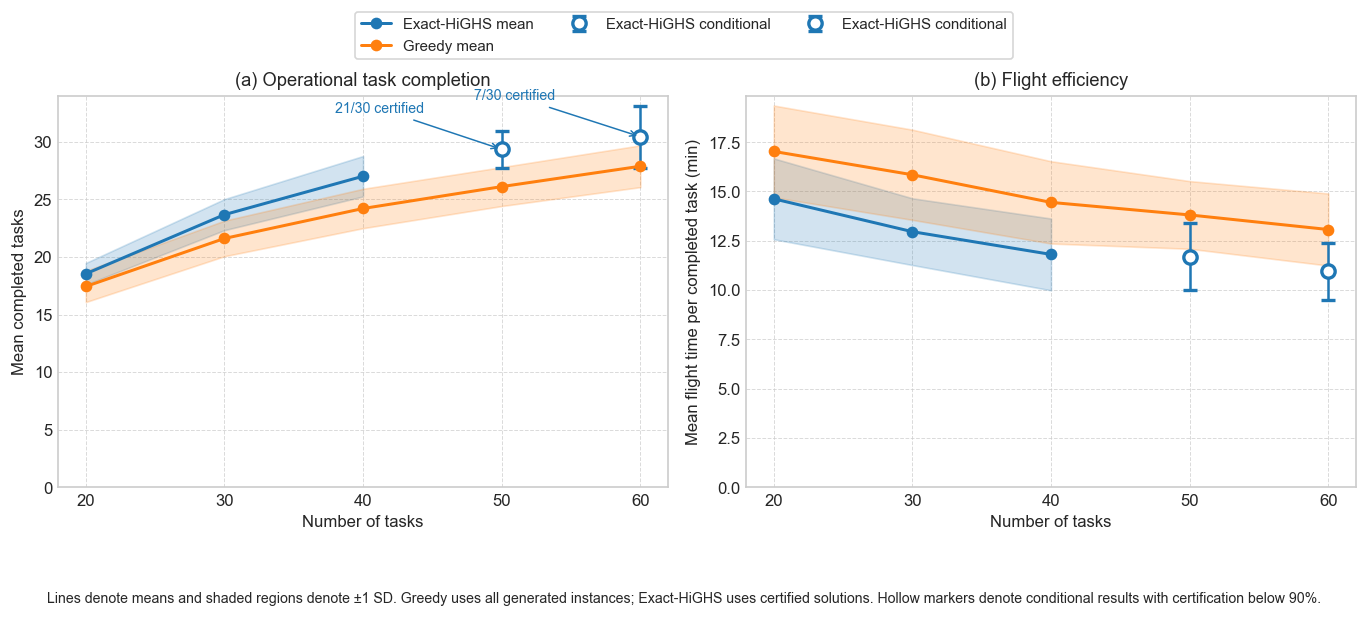

Completed-task summary:


,Tasks,mean,std,count,Method
0,20,17.433333,1.356551,30,Greedy
1,30,21.600000,1.544735,30,Greedy
2,40,24.200000,1.710011,30,Greedy
3,50,26.100000,1.688705,30,Greedy
4,60,27.866667,1.814374,30,Greedy
5,20,18.533333,0.937102,30,Exact-HiGHS certified
6,30,23.666667,1.347625,30,Exact-HiGHS certified
7,40,27.000000,1.752549,29,Exact-HiGHS certified
8,50,29.333333,1.591645,21,Exact-HiGHS certified
9,60,30.428571,2.699206,7,Exact-HiGHS certified


Flight-efficiency summary:


,Tasks,mean,std,count,Method
0,20,17.030619,2.326663,30,Greedy
1,30,15.846660,2.286716,30,Greedy
2,40,14.446329,2.086294,30,Greedy
3,50,13.809973,1.716106,30,Greedy
4,60,13.070648,1.827542,30,Greedy
5,20,14.627607,2.049754,30,Exact-HiGHS certified
6,30,12.961223,1.692324,30,Exact-HiGHS certified
7,40,11.808656,1.819521,29,Exact-HiGHS certified
8,50,11.690412,1.685566,21,Exact-HiGHS certified
9,60,10.954817,1.449977,7,Exact-HiGHS certified


In [42]:
# ============================================================
# EXPERIMENT B
# OPERATIONAL EFFECTIVENESS AND FLIGHT EFFICIENCY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SHOW_CONDITIONAL_EXACT = True
MIN_CERTIFICATION_RATE = 0.90

metrics = df_metrics_scaling.copy()

# Tiempo total de vuelo por tarea completada
metrics["Flight Time per Completed Task"] = np.where(
    metrics["Physical Completed Tasks"] > 0,
    (
        metrics["Total Flight Time"]
        / metrics["Physical Completed Tasks"]
    ),
    np.nan,
)

greedy = metrics[
    metrics["Method"] == "Greedy"
].copy()

exact = metrics[
    metrics["Method"] == "Exact-HiGHS"
].copy()

exact_certified = exact[
    exact["Optimal Certified"] == True
].copy()

task_sizes = sorted(
    greedy["Tasks"].dropna().unique()
)

# ============================================================
# COBERTURA EXACT
# ============================================================

generated_counts = (
    greedy.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

certified_counts = (
    exact_certified.groupby("Tasks")["Scenario"]
    .nunique()
    .reindex(task_sizes, fill_value=0)
)

certification_rate = (
    certified_counts / generated_counts
)

reliable_tasks = certification_rate[
    certification_rate >= MIN_CERTIFICATION_RATE
].index.tolist()

conditional_tasks = certification_rate[
    certification_rate < MIN_CERTIFICATION_RATE
].index.tolist()

# Colores originales de Matplotlib
EXACT_COLOR = "#1f77b4"
GREEDY_COLOR = "#ff7f0e"


# ============================================================
# FUNCIÓN AUXILIAR
# ============================================================

def summarize_metric(data, metric):

    return (
        data.groupby("Tasks")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("Tasks")
    )


def plot_operational_metric(
    ax,
    metric,
    ylabel,
    panel_title,
    add_labels=False,
):

    greedy_summary = summarize_metric(
        greedy,
        metric,
    )

    exact_summary = summarize_metric(
        exact_certified,
        metric,
    )

    # --------------------------------------------------------
    # EXACT CERTIFICADO: línea azul y banda ±1 SD
    # --------------------------------------------------------

    exact_reliable = exact_summary[
        exact_summary["Tasks"].isin(
            reliable_tasks
        )
    ]

    x_exact = exact_reliable["Tasks"].to_numpy()
    y_exact = exact_reliable["mean"].to_numpy()
    sd_exact = (
        exact_reliable["std"]
        .fillna(0.0)
        .to_numpy()
    )

    ax.plot(
        x_exact,
        y_exact,
        marker="o",
        color=EXACT_COLOR,
        linewidth=1.8,
        label=(
            "Exact-HiGHS mean"
            if add_labels
            else None
        ),
    )

    ax.fill_between(
        x_exact,
        y_exact - sd_exact,
        y_exact + sd_exact,
        color=EXACT_COLOR,
        alpha=0.20,
    )

    # --------------------------------------------------------
    # EXACT CONDICIONAL: marcador vacío
    # --------------------------------------------------------

    if SHOW_CONDITIONAL_EXACT:

        exact_conditional = exact_summary[
            exact_summary["Tasks"].isin(
                conditional_tasks
            )
        ]

        for _, row in exact_conditional.iterrows():

            task_count = int(row["Tasks"])
            mean_value = row["mean"]

            std_value = (
                0.0
                if pd.isna(row["std"])
                else row["std"]
            )

            certified_n = int(row["count"])
            generated_n = int(
                generated_counts.loc[task_count]
            )

            ax.errorbar(
                task_count,
                mean_value,
                yerr=std_value,
                fmt="o",
                linestyle="none",
                markersize=8,
                markerfacecolor="white",
                markeredgecolor=EXACT_COLOR,
                markeredgewidth=2,
                ecolor=EXACT_COLOR,
                capsize=4,
                label=(
                    "Exact-HiGHS conditional"
                    if add_labels
                    else None
                ),
            )

            # Anotar solamente en el panel izquierdo
            if add_labels:

                ax.annotate(
                    (
                        f"{certified_n}/"
                        f"{generated_n} certified"
                    ),
                    xy=(
                        task_count,
                        mean_value,
                    ),
                    xytext=(-100, 22),
                    textcoords="offset points",
                    fontsize=8.5,
                    color=EXACT_COLOR,
                    arrowprops={
                        "arrowstyle": "->",
                        "color": EXACT_COLOR,
                        "linewidth": 0.9,
                    },
                )

    # --------------------------------------------------------
    # GREEDY: las 30 instancias
    # --------------------------------------------------------

    x_greedy = greedy_summary["Tasks"].to_numpy()
    y_greedy = greedy_summary["mean"].to_numpy()

    sd_greedy = (
        greedy_summary["std"]
        .fillna(0.0)
        .to_numpy()
    )

    ax.plot(
        x_greedy,
        y_greedy,
        marker="o",
        color=GREEDY_COLOR,
        linewidth=1.8,
        label=(
            "Greedy mean"
            if add_labels
            else None
        ),
    )

    ax.fill_between(
        x_greedy,
        y_greedy - sd_greedy,
        y_greedy + sd_greedy,
        color=GREEDY_COLOR,
        alpha=0.20,
    )

    # --------------------------------------------------------
    # Configuración
    # --------------------------------------------------------

    ax.set_xlabel("Number of tasks")
    ax.set_ylabel(ylabel)
    ax.set_title(panel_title)
    ax.set_xticks(task_sizes)
    ax.set_ylim(bottom=0)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.7,
    )


# ============================================================
# CREAR FIGURA
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.6),
)

# Panel A: tareas completadas
plot_operational_metric(
    ax=axes[0],
    metric="Physical Completed Tasks",
    ylabel="Mean completed tasks",
    panel_title="(a) Operational task completion",
    add_labels=True,
)

# Panel B: eficiencia de vuelo
plot_operational_metric(
    ax=axes[1],
    metric="Flight Time per Completed Task",
    ylabel=(
        "Mean flight time per completed task (min)"
    ),
    panel_title="(b) Flight efficiency",
    add_labels=False,
)

# ============================================================
# LEYENDA COMÚN
# ============================================================

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
    frameon=True,
)

# Nota metodológica
fig.text(
    0.5,
    -0.025,
    (
        "Lines denote means and shaded regions denote ±1 SD. "
        "Greedy uses all generated instances; Exact-HiGHS uses "
        "certified solutions. Hollow markers denote conditional "
        "results with certification below 90%."
    ),
    ha="center",
    va="top",
    fontsize=8.5,
)

fig.tight_layout(
    rect=[0, 0.055, 1, 0.95]
)

# ============================================================
# GUARDAR
# ============================================================

save_current_figure(
    save_name=(
        "fig_expB_operational_effectiveness_"
        "and_flight_efficiency.png"
    ),
    dpi=1000,
)

plt.show()

# ============================================================
# TABLAS DE CONTROL
# ============================================================

completed_summary = pd.concat(
    [
        summarize_metric(
            greedy,
            "Physical Completed Tasks",
        ).assign(Method="Greedy"),
        summarize_metric(
            exact_certified,
            "Physical Completed Tasks",
        ).assign(Method="Exact-HiGHS certified"),
    ],
    ignore_index=True,
)

flight_efficiency_summary = pd.concat(
    [
        summarize_metric(
            greedy,
            "Flight Time per Completed Task",
        ).assign(Method="Greedy"),
        summarize_metric(
            exact_certified,
            "Flight Time per Completed Task",
        ).assign(Method="Exact-HiGHS certified"),
    ],
    ignore_index=True,
)

print("Completed-task summary:")
display(completed_summary)

print("Flight-efficiency summary:")
display(flight_efficiency_summary)